# 01 — Exploratory Data Analysis (EDA)

**Fake News & Misinformation Detector** (MSE1 · *EDA* criterion, 3 marks; also the "Before/after" section of the
*Data Preprocessing* criterion). Master doc §11.2 lists the required plots; `docs/milestones/MSE1_ProjectDetails.md` §3.4
fixes the figure names. This notebook

1. loads the **processed** parquet files produced by `make data` and the **raw** files in `data/raw/` (needed for every
   *before* artefact-removal view),
2. produces every figure of §11.2 plus the extra ones asked for in the EDA brief (DistilBERT `max_len` coverage,
   title length, leakage-token table, artefact-only classifier, LIAR speakers/subjects, WELFake↔ISOT vocabulary overlap,
   source/domain analysis), saving each to `docs/figures/eda_*.png` (200 dpi),
3. turns each figure into a **design decision** and writes `docs/eda_summary.md` (one insight line per figure).

Conventions: real = blue, fake = orange (colour-blind-safe palette validated with the data-viz checker); LIAR's six
ordinal labels use one sequential hue. Expensive steps (n-grams, word clouds, spaCy NER, the DistilBERT tokenizer,
style features) run on **fixed-seed stratified samples** — the sample size is printed next to each result. Everything
else (class balance, lengths, leakage counts, duplicates, dates, vocabulary overlap) uses the full data.
Runtime ≈ 6–10 min on an 8-thread laptop CPU (budget ≤ 20 min).

In [1]:
import gc, json, re, resource, sys, time, platform, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as C
from src.preprocess.artefacts import PATTERNS, artefact_only_accuracy
from src.preprocess.load import LIAR_COLUMNS

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 180)
FIG = C.FIGURES_DIR; FIG.mkdir(parents=True, exist_ok=True)
SEED = C.SEED
rng = np.random.default_rng(SEED)

# colour-blind-safe categorical palette (blue, orange, aqua, yellow, magenta, green, violet, red)
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
PAL = {"real": CAT[0], "fake": CAT[1]}
HILITE = CAT[7]
sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 90, "savefig.dpi": 200, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})

SAVED: dict[str, Path] = {}
NUM: dict = {}          # key numbers collected for docs/eda_summary.md
T0 = time.time()

def lap(msg=""):
    peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024
    print(f"[{time.time() - T0:6.1f} s | peak RSS {peak:5.0f} MB] {msg}")

def savefig(fig, name):
    path = FIG / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    SAVED[name] = path
    print(f"saved {path.relative_to(ROOT)}")

def pct(x, d=1):
    return f"{100 * x:.{d}f} %"

print("python", platform.python_version(), "| pandas", pd.__version__, "| figures ->", FIG.relative_to(ROOT))

python 3.11.11 | pandas 2.3.3 | figures -> docs/figures


## 1. Load processed and raw data

Processed parquet files share the schema `id, title, text, label, label5, label3, source_dataset, date, split, meta`.
The raw files are re-read only for the *before artefact-removal* views (n-grams, leakage tokens, artefact-only classifier).
Raw WELFake labels follow the verified polarity **0 = real, 1 = fake** (see `data/README.md`).

In [2]:
P = {d: pd.read_parquet(C.PROCESSED_DIR / f"{d}.parquet") for d in C.DATASETS}
for d in P:                       # plain object dtype is faster for the regex-heavy steps below
    P[d] = P[d].astype({c: object for c in ("title", "text")})
    P[d]["title"] = P[d]["title"].fillna("")
summary = {s["dataset"]: s for s in json.load(open(C.PROCESSED_DIR / "make_data_summary.json"))}

# raw files: only the columns we need, and the raw frames are released again after §7 (laptop RAM budget)
w = pd.read_csv(C.RAW_DIR / "welfake" / "WELFake_Dataset.csv", usecols=["Unnamed: 0", "title", "text", "label"])
RAW = {}
RAW["welfake"] = pd.DataFrame({"id": "welfake_" + w["Unnamed: 0"].astype(int).astype(str),
                               "title": w["title"].fillna(""), "text": w["text"].fillna(""),
                               "label": w["label"].map({0: "real", 1: "fake"})})
del w
parts = []; subj = []; date_na = 0
for fname, lab in (("True.csv", "real"), ("Fake.csv", "fake")):
    t = pd.read_csv(C.RAW_DIR / "isot" / fname)
    parts.append(pd.DataFrame({"id": f"isot_{lab}_" + pd.RangeIndex(len(t)).astype(str), "title": t["title"].fillna(""),
                               "text": t["text"].fillna(""), "label": lab}))
    subj.append(t["subject"].value_counts().rename(lab))
    date_na += int(pd.to_datetime(t["date"], errors="coerce", format="mixed").isna().sum())
RAW["isot"] = pd.concat(parts, ignore_index=True); del parts, t
ISOT_SUBJECT_X = pd.concat(subj, axis=1).fillna(0).astype(int)[["fake", "real"]]   # raw subject × class (used in §16)
ISOT_RAW_DATE_NA = date_na                                                          # raw rows with an unparseable date (§11)
gc.collect()

rows = []
for d, df in P.items():
    rows.append({"dataset": d, "rows_processed": len(df), "rows_raw": summary[d]["rows_in"],
                 "labels": df["label"].value_counts().to_dict(), "splits": df["split"].value_counts().to_dict()})
lap("loaded")
pd.DataFrame(rows)

[   5.2 s | peak RSS  1553 MB] loaded


,dataset,rows_processed,rows_raw,labels,splits
0,welfake,60847,72134,"{'real': 34296, 'fake': 26551}","{'train': 48677, 'val': 6085, 'test': 6085}"
1,isot,37608,44898,"{'real': 20905, 'fake': 16703}","{'train': 30086, 'val': 3761, 'test': 3761}"
2,liar,12836,12836,"{'half-true': 2638, 'false': 2511, 'mostly-true': 2466, 'barely-true': 2108, 'true': 2063, 'pants-fire': 1050}","{'train': 10269, 'val': 1284, 'test': 1283}"
3,fever_subset,23000,165447,"{'REFUTES': 7667, 'NEUTRAL': 7667, 'SUPPORTS': 7666}","{'train': 20000, 'val': 3000}"
4,fnn_politifact,1056,1056,"{'real': 624, 'fake': 432}",{}


## 2. Class balance per dataset  → `eda_class_balance.png`

Raw vs. processed counts for the two article corpora (dedup removed mostly *fake* rows), LIAR 6-way with the
5-class and 3-class mappings, the balanced FEVER subset and the FakeNewsNet PolitiFact titles.

saved docs/figures/eda_class_balance.png


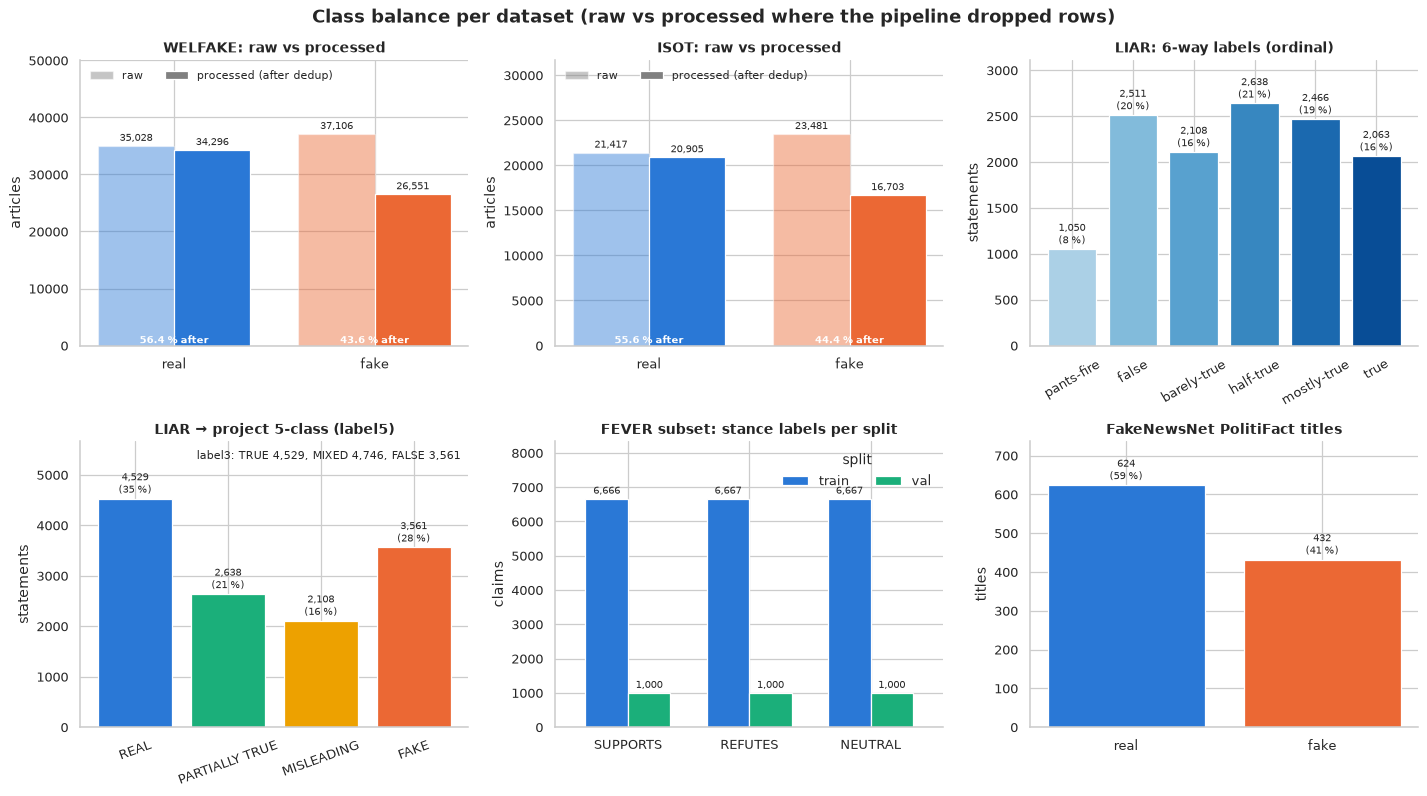

WELFake real share raw -> processed: 48.6 % -> 56.4 % | 93.5 % of the dropped rows were fake
ISOT    real share raw -> processed: 47.7 % -> 55.6 % | 93.0 % of the dropped rows were fake
LIAR majority class share: 20.6 % | max/min class ratio: 2.51
balanced class weights, LIAR 6-way: {'pants-fire': 2.04, 'false': 0.85, 'barely-true': 1.01, 'half-true': 0.81, 'mostly-true': 0.87, 'true': 1.04}
balanced class weights, LIAR 3-way: {'TRUE': 0.94, 'MIXED': 0.9, 'FALSE': 1.2}


In [3]:
LIAR_ORDER = C.LIAR_LABELS                       # pants-fire ... true (ordinal)
L5_ORDER = ["REAL", "PARTIALLY TRUE", "MISLEADING", "FAKE"]
L3_ORDER = ["TRUE", "MIXED", "FALSE"]

def annotate(ax, fmt="{:,}", total=None, fontsize=8):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            s = fmt.format(int(h)) + (f"\n({100 * h / total:.0f} %)" if total else "")
            ax.annotate(s, (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=fontsize, xytext=(0, 2),
                        textcoords="offset points")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
balance = {}
for ax, d in zip(axes[0, :2], ("welfake", "isot")):
    raw_c = RAW[d]["label"].value_counts(); proc_c = P[d]["label"].value_counts()
    bal = pd.DataFrame({"raw": raw_c, "processed": proc_c}).loc[["real", "fake"]]
    balance[d] = bal
    x = np.arange(2); wd = 0.38
    ax.bar(x - wd / 2, bal["raw"], wd, color=[PAL["real"], PAL["fake"]], alpha=0.45, label="raw", edgecolor="white")
    ax.bar(x + wd / 2, bal["processed"], wd, color=[PAL["real"], PAL["fake"]], label="processed (after dedup)", edgecolor="white")
    ax.set_xticks(x, ["real", "fake"]); ax.set_ylabel("articles"); ax.set_title(f"{d.upper()}: raw vs processed")
    annotate(ax, total=None); ax.set_ylim(0, bal.values.max() * 1.35)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor="grey", alpha=0.45, label="raw"), Patch(facecolor="grey", label="processed (after dedup)")], loc="upper left", ncol=2, fontsize=9)
    for i, lab in enumerate(["real", "fake"]):
        ax.text(i, 0, f"{100 * bal.loc[lab, 'processed'] / bal['processed'].sum():.1f} % after", ha="center", va="bottom",
                fontsize=8, color="white", fontweight="bold")
ax = axes[0, 2]
lc = P["liar"]["label"].value_counts().reindex(LIAR_ORDER)
cols_liar = sns.color_palette("Blues", n_colors=8)[2:]
ax.bar(LIAR_ORDER, lc.values, color=cols_liar, edgecolor="white"); ax.set_title("LIAR: 6-way labels (ordinal)")
ax.set_ylabel("statements"); ax.tick_params(axis="x", rotation=30); annotate(ax, total=len(P["liar"])); ax.set_ylim(0, lc.max() * 1.18)
ax = axes[1, 0]
l5 = P["liar"]["label5"].value_counts().reindex(L5_ORDER)
ax.bar(L5_ORDER, l5.values, color=[CAT[0], CAT[2], CAT[3], CAT[1]], edgecolor="white"); ax.set_title("LIAR → project 5-class (label5)")
ax.set_ylabel("statements"); ax.tick_params(axis="x", rotation=20); annotate(ax, total=len(P["liar"])); ax.set_ylim(0, l5.max() * 1.25)
l3 = P["liar"]["label3"].value_counts().reindex(L3_ORDER)
ax.text(0.98, 0.97, "label3: " + ", ".join(f"{k} {v:,}" for k, v in l3.items()), transform=ax.transAxes, ha="right", va="top", fontsize=9)
ax = axes[1, 1]
fv = pd.crosstab(P["fever_subset"]["label"], P["fever_subset"]["split"]).reindex(["SUPPORTS", "REFUTES", "NEUTRAL"])
fv.plot.bar(ax=ax, color=[CAT[0], CAT[2]], edgecolor="white", width=0.7); ax.set_title("FEVER subset: stance labels per split")
ax.set_ylabel("claims"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0); ax.set_ylim(0, fv.values.max() * 1.25); ax.legend(title="split", loc="upper right", ncol=2)
annotate(ax)
ax = axes[1, 2]
fc = P["fnn_politifact"]["label"].value_counts().reindex(["real", "fake"])
ax.bar(fc.index, fc.values, color=[PAL["real"], PAL["fake"]], edgecolor="white"); ax.set_title("FakeNewsNet PolitiFact titles")
ax.set_ylabel("titles"); annotate(ax, total=len(P["fnn_politifact"])); ax.set_ylim(0, fc.max() * 1.18)
fig.suptitle("Class balance per dataset (raw vs processed where the pipeline dropped rows)", fontsize=14, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_class_balance"); plt.show()

for d in ("welfake", "isot"):
    b = balance[d]; NUM[f"{d}_real_share_raw"] = b.loc["real", "raw"] / b["raw"].sum()
    NUM[f"{d}_real_share_proc"] = b.loc["real", "processed"] / b["processed"].sum()
    NUM[f"{d}_dropped_fake_share"] = (b.loc["fake", "raw"] - b.loc["fake", "processed"]) / (b["raw"].sum() - b["processed"].sum())
NUM["liar_6way"] = lc.to_dict(); NUM["liar_label5"] = l5.to_dict(); NUM["liar_label3"] = l3.to_dict()
NUM["liar_majority_share"] = lc.max() / lc.sum(); NUM["liar_imbalance_ratio"] = lc.max() / lc.min()
print("WELFake real share raw -> processed:", pct(NUM["welfake_real_share_raw"]), "->", pct(NUM["welfake_real_share_proc"]),
      f"| {pct(NUM['welfake_dropped_fake_share'])} of the dropped rows were fake")
print("ISOT    real share raw -> processed:", pct(NUM["isot_real_share_raw"]), "->", pct(NUM["isot_real_share_proc"]),
      f"| {pct(NUM['isot_dropped_fake_share'])} of the dropped rows were fake")
print("LIAR majority class share:", pct(NUM["liar_majority_share"]), "| max/min class ratio:", round(NUM["liar_imbalance_ratio"], 2))
from sklearn.utils.class_weight import compute_class_weight
cw6 = compute_class_weight("balanced", classes=np.array(LIAR_ORDER), y=P["liar"]["label"].to_numpy())
cw3 = compute_class_weight("balanced", classes=np.array(L3_ORDER), y=P["liar"]["label3"].to_numpy())
NUM["liar_class_weights_6"] = {k: round(float(v), 2) for k, v in zip(LIAR_ORDER, cw6)}; NUM["liar_class_weights_3"] = {k: round(float(v), 2) for k, v in zip(L3_ORDER, cw3)}
print("balanced class weights, LIAR 6-way:", NUM["liar_class_weights_6"]); print("balanced class weights, LIAR 3-way:", NUM["liar_class_weights_3"])

## 3. Text length per class → `eda_length_hist.png`, DistilBERT `max_len` coverage → `eda_maxlen_coverage.png`, title length → `eda_title_length.png`

Whitespace-token lengths use the **full** processed corpora. Sub-word lengths come from the real `distilbert-base-uncased`
tokenizer on a stratified sample (title + `[SEP]` + text, the input format planned for fine-tuning), which is what decides
`max_len`.

count   mean    5%    25%    50%    75%     90%     95%     99%
        label                                                                   
welfake fake   26551.0  509.0  57.0  255.0  380.0  557.0   905.0  1315.0  2886.0
        real   34296.0  580.0  70.0  244.0  428.0  785.0  1185.0  1424.0  2495.0
isot    fake   16703.0  427.0  81.0  286.0  376.0  501.0   667.0   831.0  1604.0
        real   20905.0  381.0  63.0  145.0  356.0  518.0   769.0   887.0  1141.0

saved docs/figures/eda_length_hist.png


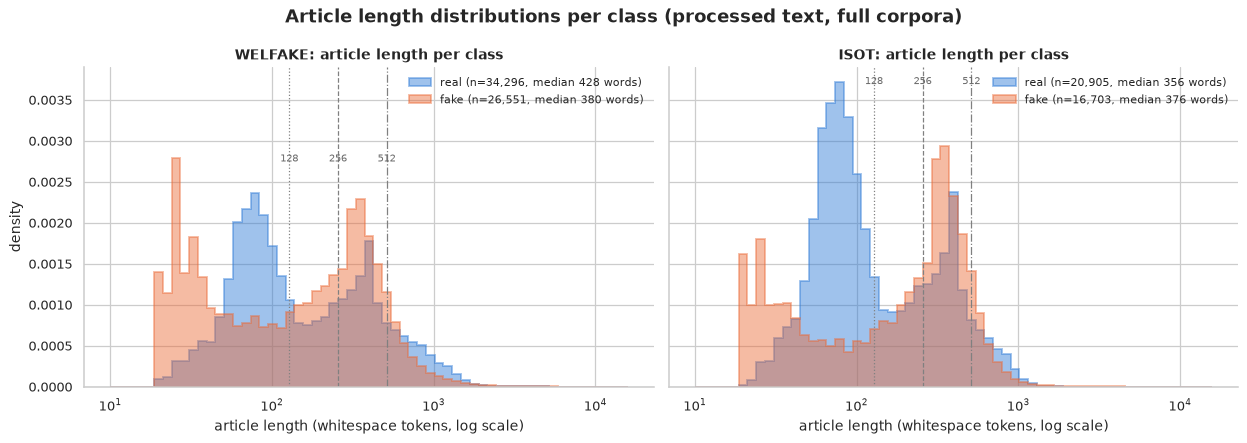

welfake median words per class {'fake': 380.0, 'real': 428.0} | share < 100 words {'fake': 0.083, 'real': 0.113} | share > 1000 words {'fake': 0.085, 'real': 0.153}
isot median words per class {'fake': 376.0, 'real': 356.0} | share < 100 words {'fake': 0.059, 'real': 0.175} | share > 1000 words {'fake': 0.03, 'real': 0.024}


In [4]:
PCTS = [5, 25, 50, 75, 90, 95, 99]
for d in ("welfake", "isot"):
    P[d]["n_words"] = P[d]["text"].str.count(r"\S+")
    P[d]["n_title_words"] = P[d]["title"].str.count(r"\S+")
len_tab = pd.concat({d: P[d].groupby("label")["n_words"].describe(percentiles=[p / 100 for p in PCTS])[
    ["count", "mean"] + [f"{p}%" for p in PCTS]] for d in ("welfake", "isot")}).round(0)
display(len_tab)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
bins = np.logspace(1, 4.2, 60)
for ax, d in zip(axes, ("welfake", "isot")):
    for lab in ("real", "fake"):
        v = P[d].loc[P[d]["label"] == lab, "n_words"].clip(upper=15000)
        ax.hist(v, bins=bins, density=True, histtype="stepfilled", alpha=0.45, color=PAL[lab], edgecolor=PAL[lab], lw=1.5,
                label=f"{lab} (n={len(v):,}, median {int(v.median())} words)")
    for L, ls in ((128, ":"), (256, "--"), (512, "-.")):
        ax.axvline(L, color="grey", ls=ls, lw=1); ax.text(L, ax.get_ylim()[1] * 0.97, f"{L}", ha="center", va="top", fontsize=8, color="dimgrey")
    ax.set_xscale("log"); ax.set_xlabel("article length (whitespace tokens, log scale)"); ax.set_title(f"{d.upper()}: article length per class")
    ax.legend(loc="upper right", fontsize=9)
axes[0].set_ylabel("density")
fig.suptitle("Article length distributions per class (processed text, full corpora)", fontsize=14, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_length_hist"); plt.show()
for d in ("welfake", "isot"):
    g = P[d].groupby("label")["n_words"]
    NUM[f"{d}_median_words"] = g.median().to_dict()
    NUM[f"{d}_p95_words"] = g.quantile(0.95).round(0).to_dict()
    NUM[f"{d}_short_share"] = (P[d]["n_words"] < 100).groupby(P[d]["label"]).mean().round(3).to_dict()
    NUM[f"{d}_long_share"] = (P[d]["n_words"] > 1000).groupby(P[d]["label"]).mean().round(3).to_dict()
    print(d, "median words per class", NUM[f"{d}_median_words"], "| share < 100 words", NUM[f"{d}_short_share"], "| share > 1000 words", NUM[f"{d}_long_share"])

[  15.3 s | peak RSS  1600 MB] tokenized samples
share of documents that fit entirely (sub-word tokens incl. [CLS]/[SEP]) — sample of 4000 per dataset


,≤64,≤128,≤256,≤512,median,p95
welfake,2.1%,8.6%,19.1%,50.1%,512,1869
isot,1.2%,9.9%,21.4%,58.3%,471,1075
liar,99.9%,100.0%,100.0%,100.0%,22,42
fever_subset,100.0%,100.0%,100.0%,100.0%,12,19


median share of an article's sub-words kept by head truncation at 256 / 512: {'welfake': (0.5, 1.0), 'isot': (0.54, 1.0)}


saved docs/figures/eda_maxlen_coverage.png


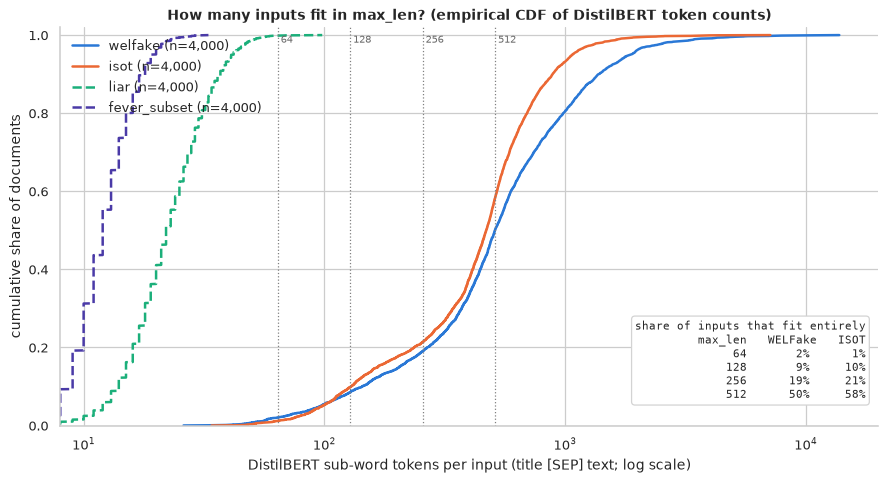

In [5]:
# the exact WordPiece tokenizer of distilbert-base-uncased, loaded through the `tokenizers` library
# (same vocabulary/normaliser as transformers' AutoTokenizer, but without importing torch — saves ~0.5 GB RAM)
from tokenizers import Tokenizer
tok = Tokenizer.from_pretrained("distilbert-base-uncased")
tok.no_truncation()
N_TOK = 4000                                              # stratified sample per dataset for the sub-word count

def n_subwords(texts, chunk=200):
    # encode in chunks and keep only the lengths: a full encode_batch materialises offsets/masks for every token (~2 GB)
    out = []
    for i in range(0, len(texts), chunk):
        out.extend(len(e.ids) for e in tok.encode_batch(texts[i:i + chunk]))   # adds [CLS] ... [SEP]
    return out

sub = {}
for d in ("welfake", "isot"):
    s = P[d].groupby("label", group_keys=False).apply(lambda g: g.sample(N_TOK // 2, random_state=SEED))
    sub[d] = pd.DataFrame({"label": s["label"].to_numpy(), "n_subwords": n_subwords((s["title"] + " [SEP] " + s["text"]).tolist())})
for d in ("liar", "fever_subset"):
    s = P[d].sample(N_TOK, random_state=SEED)
    sub[d] = pd.DataFrame({"label": s["label"].to_numpy(), "n_subwords": n_subwords(s["text"].tolist())})
lap("tokenized samples")

LENS = [64, 128, 256, 512]
cov = pd.DataFrame({d: {f"≤{L}": (v["n_subwords"] <= L).mean() for L in LENS} | {"median": v["n_subwords"].median(),
                        "p95": v["n_subwords"].quantile(0.95)} for d, v in sub.items()}).T
cov_cls = pd.DataFrame({(d, lab): {f"≤{L}": (v.loc[v.label == lab, "n_subwords"] <= L).mean() for L in LENS}
                        for d in ("welfake", "isot") for v in [sub[d]] for lab in ("real", "fake")}).T
print("share of documents that fit entirely (sub-word tokens incl. [CLS]/[SEP]) — sample of", N_TOK, "per dataset")
display(cov.style.format({c: "{:.1%}" for c in cov.columns if c.startswith("≤")} | {"median": "{:.0f}", "p95": "{:.0f}"}))
display(cov_cls.style.format("{:.1%}"))
for d in ("welfake", "isot"):
    v = sub[d]["n_subwords"]
    NUM[f"{d}_fit"] = {L: float((v <= L).mean()) for L in LENS}
    NUM[f"{d}_kept_frac_256"] = float(np.median(np.minimum(256, v) / v))
    NUM[f"{d}_kept_frac_512"] = float(np.median(np.minimum(512, v) / v))
NUM["liar_fit"] = {L: float((sub["liar"]["n_subwords"] <= L).mean()) for L in (64, 128)}
NUM["fever_fit"] = {L: float((sub["fever_subset"]["n_subwords"] <= L).mean()) for L in (64, 128)}
NUM["fever_claim_p95_subwords"] = float(sub["fever_subset"]["n_subwords"].quantile(0.95))
print("median share of an article's sub-words kept by head truncation at 256 / 512:",
      {d: (round(NUM[f'{d}_kept_frac_256'], 2), round(NUM[f'{d}_kept_frac_512'], 2)) for d in ("welfake", "isot")})

fig, ax = plt.subplots(figsize=(10, 5.5))
styles = {"welfake": (CAT[0], "-"), "isot": (CAT[1], "-"), "liar": (CAT[2], "--"), "fever_subset": (CAT[6], "--")}
for d, v in sub.items():
    x = np.sort(v["n_subwords"].to_numpy()); y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, color=styles[d][0], ls=styles[d][1], lw=2, label=f"{d} (n={len(x):,})")
for L in LENS:
    ax.axvline(L, color="grey", ls=":", lw=1)
    ax.text(L, 1.0, f" {L}", ha="left", va="top", fontsize=8, color="dimgrey")
box = "share of inputs that fit entirely\nmax_len   WELFake   ISOT\n" + "\n".join(f"{L:>7d}   {NUM['welfake_fit'][L]:>6.0%}   {NUM['isot_fit'][L]:>5.0%}" for L in LENS)
ax.text(0.985, 0.06, box, transform=ax.transAxes, ha="right", va="bottom", fontsize=9, family="monospace",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="lightgrey"))
ax.set_xscale("log"); ax.set_xlim(8, 20000); ax.set_ylim(0, 1.02)
ax.set_xlabel("DistilBERT sub-word tokens per input (title [SEP] text; log scale)"); ax.set_ylabel("cumulative share of documents")
ax.set_title("How many inputs fit in max_len? (empirical CDF of DistilBERT token counts)")
ax.legend(loc="upper left"); fig.tight_layout(); savefig(fig, "eda_maxlen_coverage"); plt.show()

saved docs/figures/eda_title_length.png


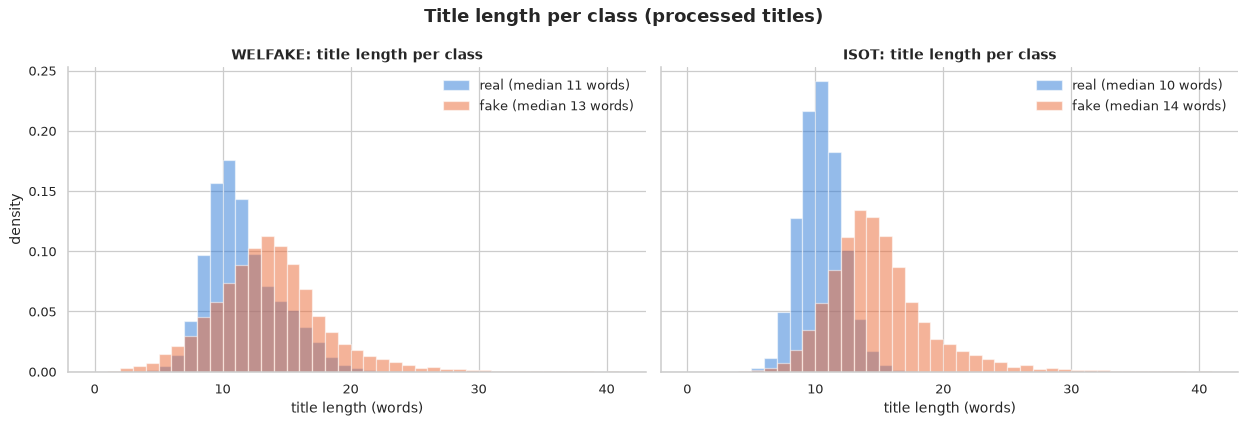

,titles_present,median_words_real,median_words_fake,share_title_≥50%_CAPS_real,share_title_≥50%_CAPS_fake
welfake,99.5 %,11.0,13.0,0.000087,0.041608
isot,100.0 %,10.0,14.0,0.0,0.053224


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
title_tab = {}
for ax, d in zip(axes, ("welfake", "isot")):
    has = P[d]["title"] != ""
    for lab in ("real", "fake"):
        v = P[d].loc[has & (P[d]["label"] == lab), "n_title_words"].clip(upper=40)
        ax.hist(v, bins=np.arange(0, 42, 1), density=True, alpha=0.5, color=PAL[lab], label=f"{lab} (median {int(v.median())} words)")
    caps = P[d].loc[has].assign(caps=lambda x: x["title"].str.count(r"\b[A-Z]{3,}\b") / x["n_title_words"].clip(lower=1))
    title_tab[d] = {"titles_present": pct(has.mean()), **{f"median_words_{lab}": P[d].loc[has & (P[d].label == lab), "n_title_words"].median() for lab in ("real", "fake")},
                    **{f"share_title_≥50%_CAPS_{lab}": caps.loc[caps.label == lab, "caps"].ge(0.5).mean() for lab in ("real", "fake")}}
    ax.set_title(f"{d.upper()}: title length per class"); ax.set_xlabel("title length (words)"); ax.legend()
axes[0].set_ylabel("density")
fig.suptitle("Title length per class (processed titles)", fontsize=14, fontweight="bold"); fig.tight_layout(); savefig(fig, "eda_title_length"); plt.show()
NUM["title"] = title_tab
display(pd.DataFrame(title_tab).T)

## 4. Before / after artefact removal — five examples

Rows are matched by `id` between the raw files and the processed parquet, so the only differences are the
artefact stripping (`src/preprocess/artefacts.py`) and NFKC / quote / whitespace normalisation (`clean.py`).

In [7]:
def example(d, mask_fn, where="head", n_chars=170):
    raw = RAW[d]; proc = P[d].set_index("id")
    cand = raw[raw["id"].isin(proc.index) & mask_fn(raw)].iloc[0]
    r, c = cand["text"], proc.loc[cand["id"], "text"]
    cut = (lambda s: s[:n_chars] + " …") if where == "head" else (lambda s: "… " + s[-n_chars:])
    return {"id": cand["id"], "label": cand["label"], "raw": cut(r), "processed": cut(c), "chars raw→proc": f"{len(r)}→{len(c)}"}

examples = pd.DataFrame([
    example("isot", lambda r: r["text"].str.contains(r"^WASHINGTON \(Reuters\) - ")),
    example("isot", lambda r: r["text"].str.contains(r"^[A-Z][A-Za-z ]+/[A-Z ]+\(Reuters\) - ")),
    example("welfake", lambda r: r["text"].str.contains(r"^\w[\w ]*\(Reuters\) - ")),
    example("welfake", lambda r: r["text"].str.contains(r"Featured image via", regex=False) & (r["label"] == "fake"), where="tail"),
    example("welfake", lambda r: r["text"].str.contains(r"pic\.twitter\.com/\S+") & r["text"].str.contains(r"(?<![\w])@\w+"), where="tail"),
])
with pd.option_context("display.max_colwidth", 200):
    display(examples.set_index(["id", "label"]))

,,raw,processed,chars raw→proc
id,label,,,
isot_real_0,real,"WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax c …","The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a "" …",4659→4632
isot_real_4,real,"SEATTLE/WASHINGTON (Reuters) - President Donald Trump called on the U.S. Postal Service on Friday to charge “much more” to ship packages for Amazon (AMZN.O), picking anot …","President Donald Trump called on the U.S. Postal Service on Friday to charge ""much more"" to ship packages for Amazon (AMZN.O), picking another fight with an online retail …",5204→5161
welfake_11,real,"BRUSSELS (Reuters) - British Prime Minister Theresa May s offer of settled status for EU residents is flawed and will leave them with fewer rights after Brexit, the Eur …","British Prime Minister Theresa May s offer of settled status for EU residents is flawed and will leave them with fewer rights after Brexit, the European Parliament s Brex …",2312→2271
welfake_22,fake,"… ood, as even Hillary Clinton witch hunter, Congressman Jason Chaffetz, admits that Flynn likely committed crimes.Watch this all happen below:Featured image via screengrab","… ible for Flynn which is not good, as even Hillary Clinton witch hunter, Congressman Jason Chaffetz, admits that Flynn likely committed crimes.Watch this all happen below:",2123→2077
welfake_36,fake,"… m going to run in 2020. Reporter: For what? Biden: For president! What the hell, man? https://t.co/fsRl25AD12 pic.twitter.com/GMco1PkJiL CNN (@CNN) December 6, 2016","… VP Joe Biden: Yeah, I m going to run in 2020. Reporter: For what? Biden: For president! What the hell, man? CNN ( ) December 6, 2016",192→132


## 5. Top unigrams / bigrams per class, before vs after artefact removal → `eda_top_ngrams_before.png`, `eda_top_ngrams_after.png`

Sample: **5,000 documents per class per dataset** (seed 42), *the same ids* in both views, so the only difference is
the preprocessing. sklearn's English stop-word list is applied (minus `via`, a known leakage token from
"Featured image via …"). Bars highlighted in red are tokens that are in the top-20 **before** removal but **not after** —
those are the artefact / leakage tokens.

[  26.1 s | peak RSS  1744 MB] n-grams isot


[  33.4 s | peak RSS  1761 MB] n-grams welfake


saved docs/figures/eda_top_ngrams_before.png


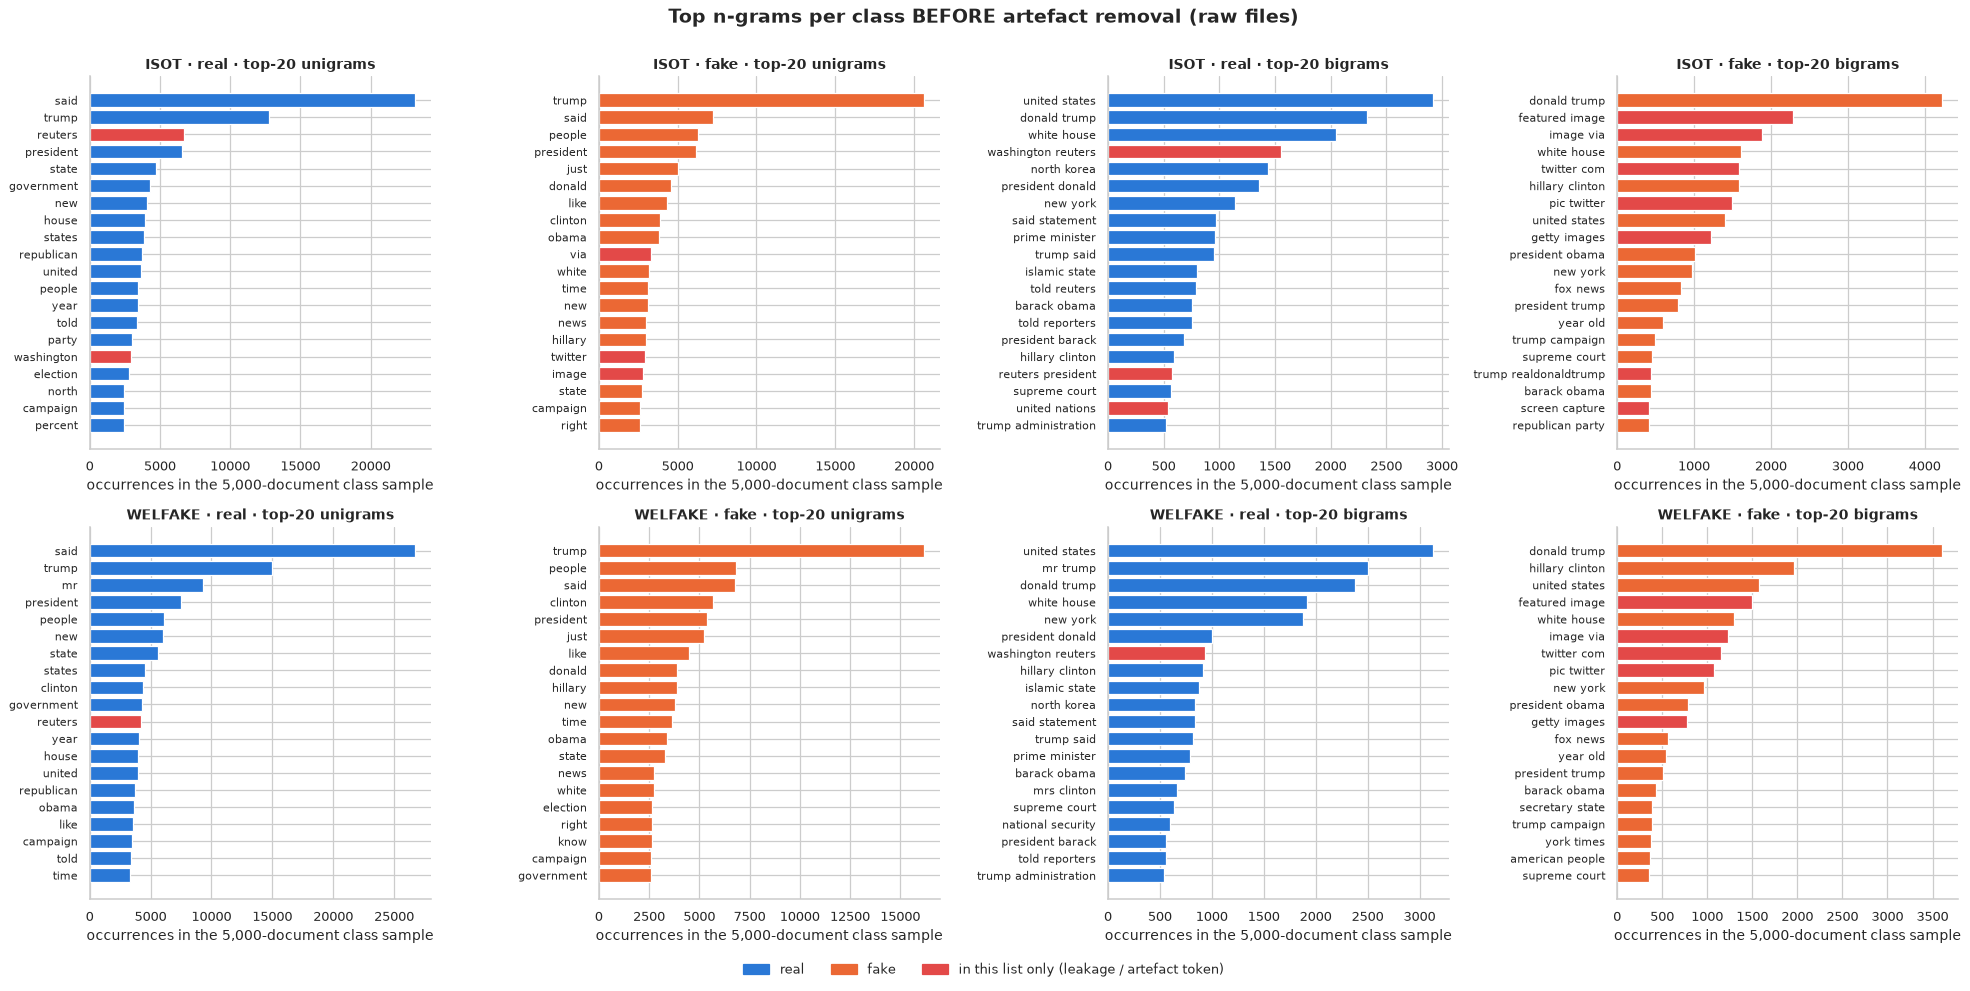

saved docs/figures/eda_top_ngrams_after.png


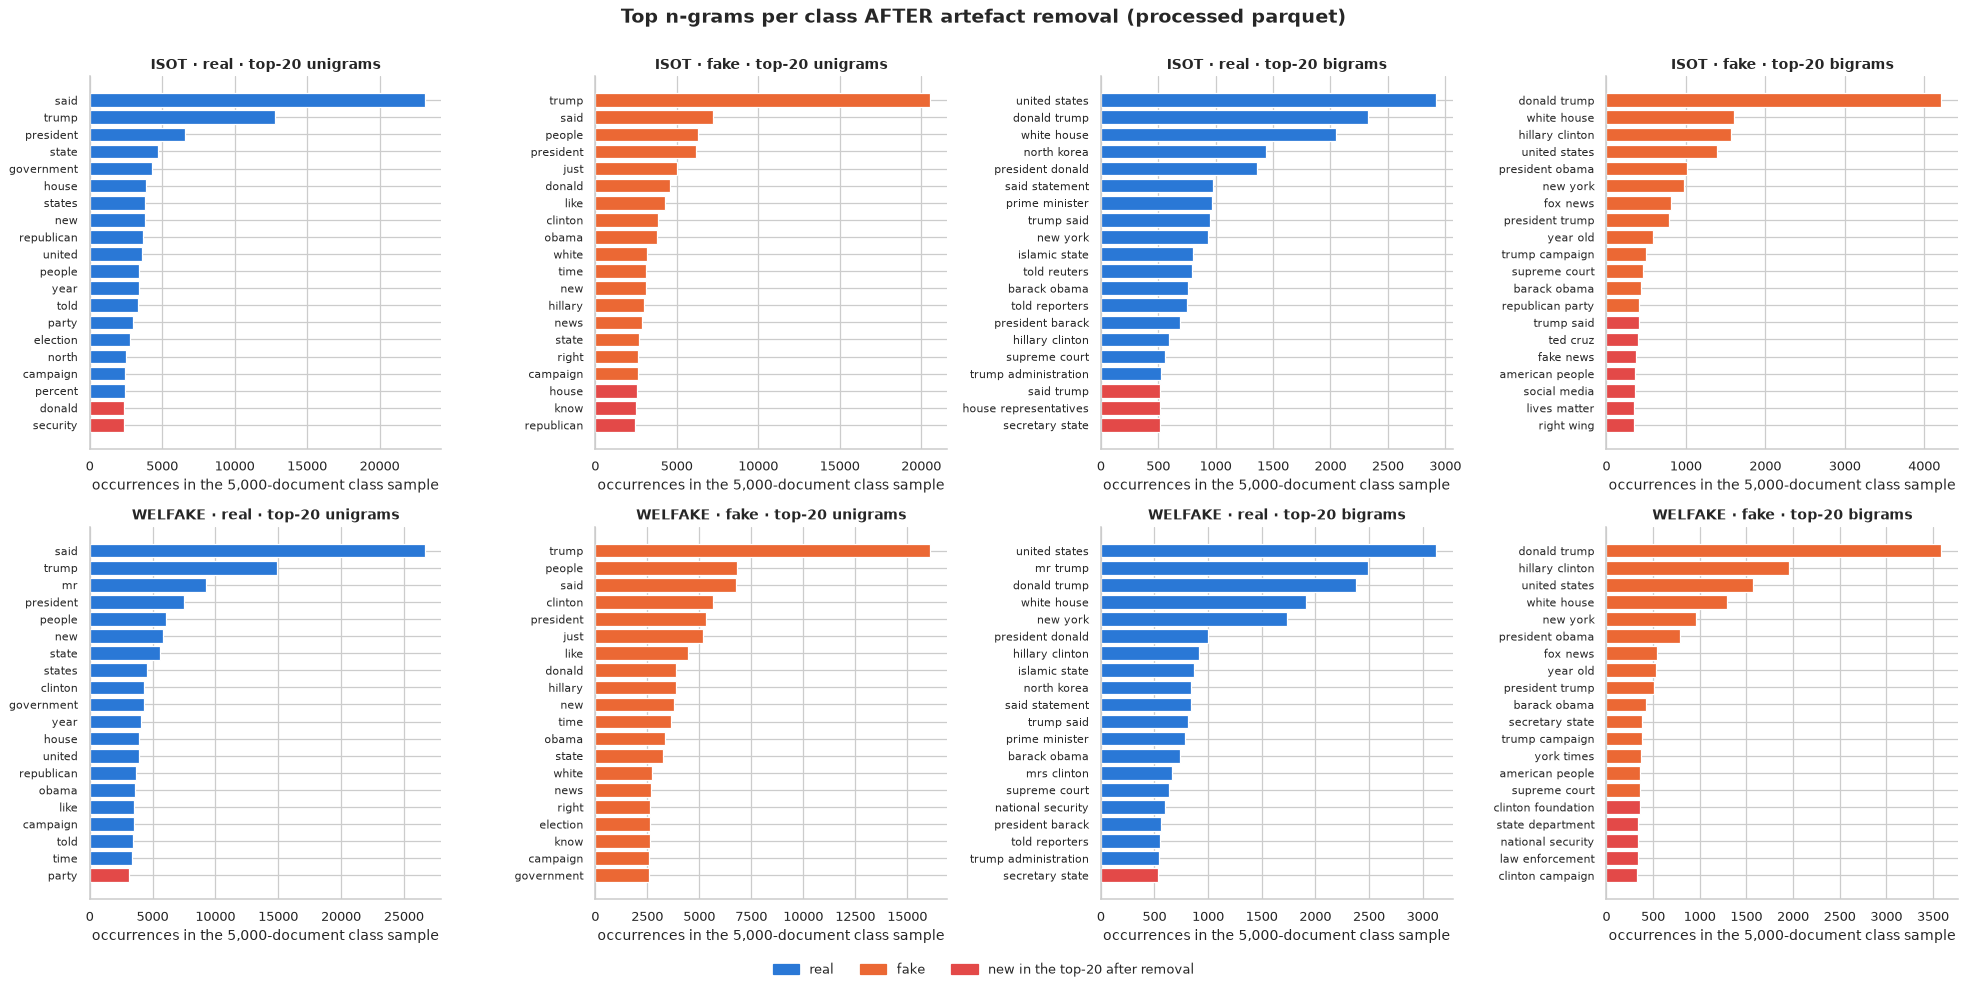

tokens that leave the top-20 after artefact removal:
  isot/real/uni      ['reuters', 'washington']
  isot/real/bi       ['reuters president', 'united nations', 'washington reuters']
  isot/fake/uni      ['image', 'twitter', 'via']
  isot/fake/bi       ['featured image', 'getty images', 'image via', 'pic twitter', 'screen capture', 'trump realdonaldtrump', 'twitter com']
  welfake/real/uni   ['reuters']
  welfake/real/bi    ['washington reuters']
  welfake/fake/uni   []
  welfake/fake/bi    ['featured image', 'getty images', 'image via', 'pic twitter', 'twitter com']


In [8]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
STOP = set(ENGLISH_STOP_WORDS) - {"via"}
TOKEN_RE = re.compile(r"(?u)\b\w\w+\b")          # sklearn's default token pattern, lower-cased text
N_NG = 5000
K = 20

def top_ngrams(texts, n, k=K):
    # streaming Counter instead of CountVectorizer: same tokenisation, a fraction of the transient memory
    cnt = Counter()
    for t in texts:
        toks = [w for w in TOKEN_RE.findall(t.lower()) if w not in STOP]
        cnt.update(toks if n == 1 else (" ".join(p) for p in zip(*[toks[i:] for i in range(n)])))
    return pd.Series(dict(cnt.most_common(k)))

ng = {}   # (dataset, view, label, n) -> Series
sample_ids = {}
for d in ("isot", "welfake"):
    ids = P[d].groupby("label", group_keys=False).apply(lambda g: g.sample(N_NG, random_state=SEED))["id"]
    sample_ids[d] = ids
    before = RAW[d].set_index("id").loc[ids]; after = P[d].set_index("id").loc[ids]
    for lab in ("real", "fake"):
        for n in (1, 2):
            ng[(d, "before", lab, n)] = top_ngrams(before.loc[before.label == lab, "text"], n)
            ng[(d, "after", lab, n)] = top_ngrams(after.loc[after.label == lab, "text"], n)
    lap(f"n-grams {d}")

def plot_ngrams(view, name, title):
    fig, axes = plt.subplots(2, 4, figsize=(22, 11))
    for i, d in enumerate(("isot", "welfake")):
        for j, (lab, n) in enumerate([("real", 1), ("fake", 1), ("real", 2), ("fake", 2)]):
            ax = axes[i, j]; s = ng[(d, view, lab, n)][::-1]
            other = set(ng[(d, "after" if view == "before" else "before", lab, n)].index)
            colors = [HILITE if t not in other else PAL[lab] for t in s.index]
            ax.barh(s.index, s.values, color=colors, edgecolor="white")
            ax.set_title(f"{d.upper()} · {lab} · top-{K} {'unigrams' if n == 1 else 'bigrams'}", fontsize=11)
            ax.set_xlabel("occurrences in the 5,000-document class sample"); ax.tick_params(axis="y", labelsize=9)
    from matplotlib.patches import Patch
    lg = [Patch(color=PAL["real"], label="real"), Patch(color=PAL["fake"], label="fake"),
          Patch(color=HILITE, label="in this list only (leakage / artefact token)" if view == "before" else "new in the top-20 after removal")]
    fig.legend(handles=lg, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(title, fontsize=15, fontweight="bold"); fig.tight_layout(rect=(0, 0.02, 1, 0.98)); savefig(fig, name); plt.show()

plot_ngrams("before", "eda_top_ngrams_before", "Top n-grams per class BEFORE artefact removal (raw files)")
plot_ngrams("after", "eda_top_ngrams_after", "Top n-grams per class AFTER artefact removal (processed parquet)")

gone = {f"{d}/{lab}/{'uni' if n == 1 else 'bi'}": sorted(set(ng[(d, 'before', lab, n)].index) - set(ng[(d, 'after', lab, n)].index))
        for d in ("isot", "welfake") for lab in ("real", "fake") for n in (1, 2)}
NUM["ngrams_gone"] = gone
print("tokens that leave the top-20 after artefact removal:")
for k, v in gone.items():
    print(f"  {k:18s} {v}")

## 6. Leakage-token table (raw ISOT, raw WELFake) → `eda_leakage_tokens.png`

For every unigram (no stop-word removal, document frequency ≥ 20) we count the documents containing it in the real and
fake class of the **full raw** corpus and compute the ratio of the per-class document shares (log₂ scale, > 0 = real-leaning,
< 0 = fake-leaning). The same statistic on the **processed** text (dots) shows what artefact removal changed. The second
table tracks a fixed list of suspicious tokens.

In [9]:
def class_doc_freq(texts, labels, min_df=20):
    # per-class document frequency + term frequency of every unigram (streaming Counters; low memory)
    dfc = {"real": Counter(), "fake": Counter()}; tfc = {"real": Counter(), "fake": Counter()}; n = Counter()
    for t, lab in zip(texts, labels):
        toks = TOKEN_RE.findall(t.lower())
        tfc[lab].update(toks); dfc[lab].update(set(toks)); n[lab] += 1
    out = pd.DataFrame({"docs_real": pd.Series(dfc["real"], dtype="int64"), "docs_fake": pd.Series(dfc["fake"], dtype="int64"),
                        "tf_real": pd.Series(tfc["real"], dtype="int64"), "tf_fake": pd.Series(tfc["fake"], dtype="int64")}).fillna(0).astype("int64")
    out = out[(out["docs_real"] + out["docs_fake"]) >= min_df].sort_index()
    out.attrs["n_real"] = int(n["real"]); out.attrs["n_fake"] = int(n["fake"])
    return out

def add_ratio(df, eps=0.5):
    pr = (df["docs_real"] + eps) / (df.attrs["n_real"] + eps); pf = (df["docs_fake"] + eps) / (df.attrs["n_fake"] + eps)
    df["share_real"] = pr; df["share_fake"] = pf; df["log2_ratio"] = np.log2(pr / pf); df["ratio_real_to_fake"] = pr / pf
    return df

DF = {}
for d in ("isot", "welfake"):
    DF[(d, "raw")] = add_ratio(class_doc_freq(RAW[d]["text"], RAW[d]["label"], min_df=20)); lap(f"doc-freq raw {d}")
    DF[(d, "proc")] = add_ratio(class_doc_freq(P[d]["text"], P[d]["label"], min_df=2)); lap(f"doc-freq processed {d}")

def leakage_table(d, k=15, min_share=0.02):
    raw, proc = DF[(d, "raw")], DF[(d, "proc")]
    common = raw[(raw["share_real"] >= min_share) | (raw["share_fake"] >= min_share)].copy()
    top_real = common.nlargest(k, "log2_ratio"); top_fake = common.nsmallest(k, "log2_ratio")
    t = pd.concat([top_real, top_fake])
    t["after: log2_ratio"] = proc["log2_ratio"].reindex(t.index)
    t["after: docs_real"] = proc["docs_real"].reindex(t.index).fillna(0).astype(int)
    t["after: docs_fake"] = proc["docs_fake"].reindex(t.index).fillna(0).astype(int)
    t.index.name = "token"
    return t[["docs_real", "docs_fake", "ratio_real_to_fake", "log2_ratio", "after: docs_real", "after: docs_fake", "after: log2_ratio"]]

LEAK = {d: leakage_table(d) for d in ("isot", "welfake")}
for d in ("isot", "welfake"):
    print(f"\n{d.upper()} — raw corpus: {DF[(d, 'raw')].attrs['n_real']:,} real / {DF[(d, 'raw')].attrs['n_fake']:,} fake documents; "
          f"tokens must occur in ≥ 2 % of one class; top-15 real-leaning then top-15 fake-leaning")
    display(LEAK[d].style.format({"ratio_real_to_fake": "{:.2f}", "log2_ratio": "{:+.2f}", "after: log2_ratio": "{:+.2f}"}).background_gradient(
        subset=["log2_ratio", "after: log2_ratio"], cmap="RdBu", vmin=-6, vmax=6))

[  44.5 s | peak RSS  1761 MB] doc-freq raw isot


[  49.2 s | peak RSS  1761 MB] doc-freq processed isot


[  64.3 s | peak RSS  1761 MB] doc-freq raw welfake


[  76.6 s | peak RSS  1761 MB] doc-freq processed welfake

ISOT — raw corpus: 21,417 real / 23,481 fake documents; tokens must occur in ≥ 2 % of one class; top-15 real-leaning then top-15 fake-leaning


,docs_real,docs_fake,ratio_real_to_fake,log2_ratio,after: docs_real,after: docs_fake,after: log2_ratio
token,,,,,,,
reuters,21378,308,75.98,+6.25,4827,176,+4.45
ankara,497,17,31.17,+4.96,345,6,+5.41
km,615,23,28.72,+4.84,604,9,+5.67
2019,575,25,24.74,+4.63,559,19,+4.52
parliamentary,634,29,23.58,+4.56,619,15,+5.00
beijing,998,48,22.57,+4.50,744,34,+4.11
theresa,628,37,18.38,+4.20,606,29,+4.04
referendum,803,52,16.78,+4.07,789,35,+4.15
overhaul,638,43,16.09,+4.01,623,31,+3.98



WELFAKE — raw corpus: 35,028 real / 37,106 fake documents; tokens must occur in ≥ 2 % of one class; top-15 real-leaning then top-15 fake-leaning


,docs_real,docs_fake,ratio_real_to_fake,log2_ratio,after: docs_real,after: docs_fake,after: log2_ratio
token,,,,,,,
reuters,21643,642,35.68,+5.16,5077,422,+3.22
overhaul,885,65,14.32,+3.84,869,47,+3.82
beijing,1259,129,10.30,+3.36,1005,96,+3.01
pyongyang,719,85,8.91,+3.16,650,52,+3.26
theresa,774,110,7.42,+2.89,751,86,+2.75
tillerson,954,149,6.76,+2.76,883,100,+2.77
crackdown,833,140,6.28,+2.65,812,88,+2.83
rex,957,167,6.06,+2.60,889,119,+2.53
parliamentary,787,141,5.90,+2.56,772,103,+2.53



ISOT — fixed watch-list (document counts; ratio of per-class document shares)


,raw docs real,raw docs fake,raw ratio real/fake,proc docs real,proc docs fake,proc ratio real/fake
token,,,,,,
reuters,21378,308,75.98,4827,176,21.85
washington,8955,3286,2.99,3760,2137,1.41
said,20059,12780,1.72,19583,9649,1.62
featured,95,8109,0.01,95,1476,0.05
image,288,8989,0.04,282,1951,0.12
via,475,11194,0.05,455,3964,0.09
video,623,4903,0.14,607,3245,0.15
hillary,2133,5352,0.44,2108,3832,0.44
twitter,1756,5559,0.35,1693,2518,0.54



WELFAKE — fixed watch-list (document counts; ratio of per-class document shares)


,raw docs real,raw docs fake,raw ratio real/fake,proc docs real,proc docs fake,proc ratio real/fake
token,,,,,,
reuters,21643,642,35.68,5077,422,9.30
washington,12652,5380,2.49,7443,3576,1.61
said,31147,18519,1.78,30635,13830,1.71
featured,433,8556,0.05,432,1680,0.20
image,976,9969,0.10,968,2555,0.29
via,987,12563,0.08,964,4836,0.15
video,2150,6705,0.34,2128,4564,0.36
hillary,4711,9661,0.52,4675,6900,0.52
twitter,5672,7314,0.82,5554,3490,1.23


saved docs/figures/eda_leakage_tokens.png


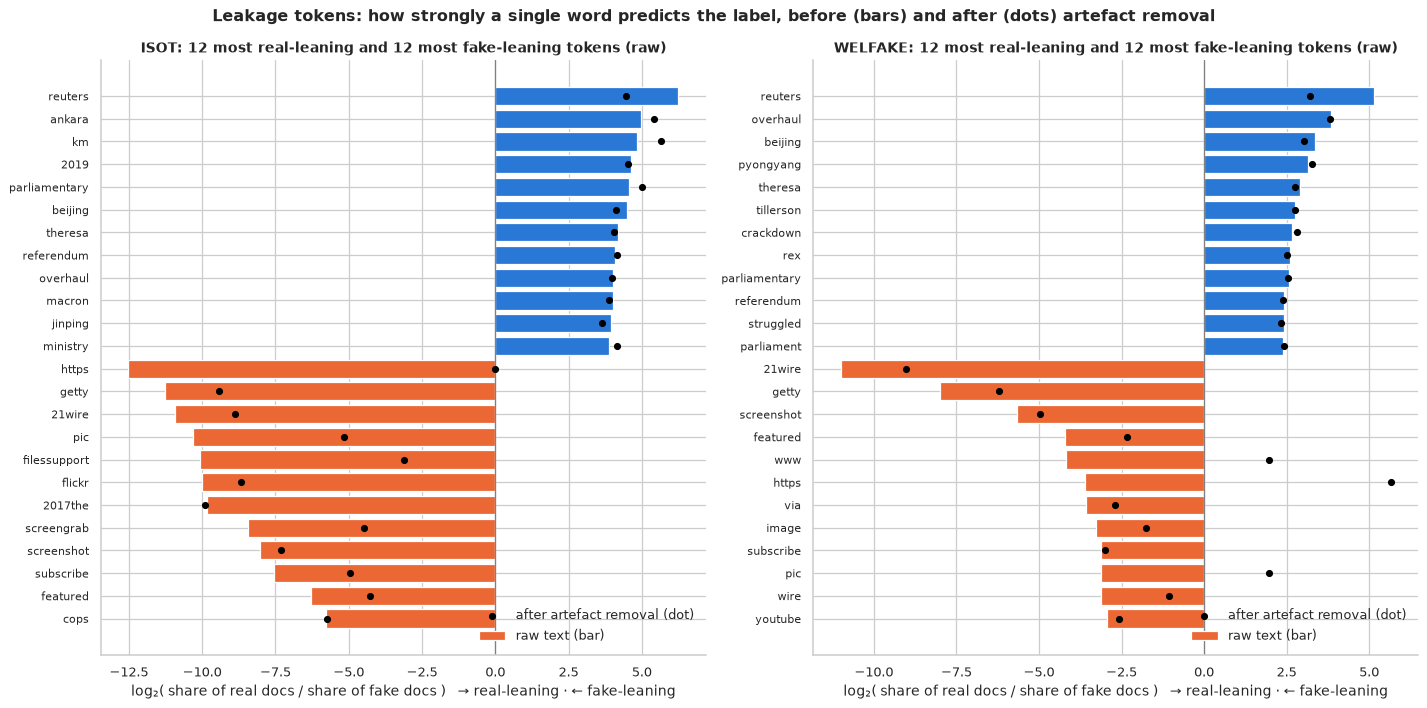

In [10]:
WATCH = ["reuters", "washington", "said", "featured", "image", "via", "video", "hillary", "twitter", "pic", "com", "http", "https",
         "realdonaldtrump", "getty", "images", "wire", "read", "editor", "told", "minister", "obama"]
def watch_table(d):
    raw, proc = DF[(d, "raw")], DF[(d, "proc")]
    t = pd.DataFrame({"raw docs real": raw["docs_real"].reindex(WATCH).fillna(0).astype(int), "raw docs fake": raw["docs_fake"].reindex(WATCH).fillna(0).astype(int),
                      "raw ratio real/fake": raw["ratio_real_to_fake"].reindex(WATCH),
                      "proc docs real": proc["docs_real"].reindex(WATCH).fillna(0).astype(int), "proc docs fake": proc["docs_fake"].reindex(WATCH).fillna(0).astype(int),
                      "proc ratio real/fake": proc["ratio_real_to_fake"].reindex(WATCH)})
    t.index.name = "token"; return t
WT = {d: watch_table(d) for d in ("isot", "welfake")}
for d in ("isot", "welfake"):
    print(f"\n{d.upper()} — fixed watch-list (document counts; ratio of per-class document shares)")
    display(WT[d].style.format({"raw ratio real/fake": "{:.2f}", "proc ratio real/fake": "{:.2f}"}, na_rep="—"))
NUM["leak"] = {d: {"top_real": LEAK[d].head(15).index.tolist()[:8], "top_fake": LEAK[d].tail(15).index.tolist()[:8],
                   "reuters_raw": (int(WT[d].loc['reuters', 'raw docs real']), int(WT[d].loc['reuters', 'raw docs fake'])),
                   "reuters_proc": (int(WT[d].loc['reuters', 'proc docs real']), int(WT[d].loc['reuters', 'proc docs fake'])),
                   "twitter_raw": (int(WT[d].loc['twitter', 'raw docs real']), int(WT[d].loc['twitter', 'raw docs fake'])),
                   "twitter_proc": (int(WT[d].loc['twitter', 'proc docs real']), int(WT[d].loc['twitter', 'proc docs fake']))}
               for d in ("isot", "welfake")}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, d in zip(axes, ("isot", "welfake")):
    t = LEAK[d].iloc[list(range(12)) + list(range(15, 27))][::-1]
    colors = [PAL["real"] if v > 0 else PAL["fake"] for v in t["log2_ratio"]]
    ax.barh(t.index, t["log2_ratio"], color=colors, edgecolor="white", label="raw text (bar)")
    ax.scatter(t["after: log2_ratio"].fillna(0), t.index, color="black", zorder=3, s=22, label="after artefact removal (dot)")
    ax.axvline(0, color="grey", lw=1); ax.set_xlabel("log₂( share of real docs / share of fake docs )   → real-leaning · ← fake-leaning")
    ax.set_title(f"{d.upper()}: 12 most real-leaning and 12 most fake-leaning tokens (raw)"); ax.tick_params(axis="y", labelsize=9)
    ax.legend(loc="lower right")
fig.suptitle("Leakage tokens: how strongly a single word predicts the label, before (bars) and after (dots) artefact removal", fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_leakage_tokens"); plt.show()

## 7. Artefact-only classifier vs. dummy baseline → `eda_artefact_classifier.png`

Replicates the check in `src/preprocess/artefacts.artefact_only_accuracy` (logistic regression on the *counts of the nine
artefact patterns only*, 5-fold stratified CV, seed 42) on raw ISOT — the value logged by `make data` is read from
`data/processed/make_data_summary.json` — and extends it to raw WELFake and to both processed corpora. The dummy
baseline is the majority-class share.

share of raw documents matching each artefact pattern, per class:


[ 110.6 s | peak RSS  1761 MB] artefact-only LR raw isot


[ 116.9 s | peak RSS  1761 MB] artefact-only LR processed isot


[ 136.8 s | peak RSS  1761 MB] artefact-only LR raw welfake


[ 150.5 s | peak RSS  1761 MB] artefact-only LR processed welfake


,dataset,text,artefact-only LR accuracy (5-fold CV),± std,majority-class dummy
0,isot,raw,0.9959,0.0005,0.5230
1,isot,processed,0.5559,0.0000,0.5559
2,welfake,raw,0.8123,0.0022,0.5144
3,welfake,processed,0.5636,0.0000,0.5636


value logged by make data for raw ISOT: 0.9959 (this run: 0.9959)
saved docs/figures/eda_artefact_classifier.png


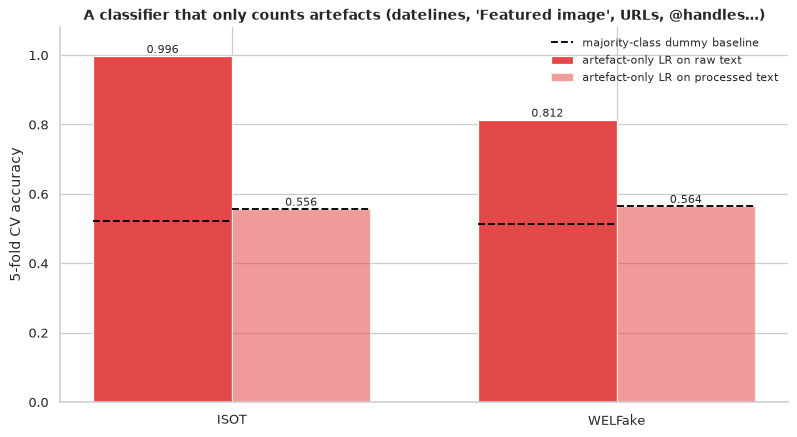

[ 150.9 s | peak RSS  1761 MB] raw frames released (everything below uses the processed parquet only)


In [11]:
per_pattern = {}
for d in ("isot", "welfake"):
    r = RAW[d]
    per_pattern[d] = pd.DataFrame({f"{lab} docs matched": [r.loc[r.label == lab, "text"].str.contains(rx, regex=True).mean() for _, rx in PATTERNS]
                                   for lab in ("real", "fake")}, index=[n for n, _ in PATTERNS])
pp = pd.concat(per_pattern, axis=1)
print("share of raw documents matching each artefact pattern, per class:")
display(pp.style.format("{:.1%}"))
NUM["pattern_share"] = {d: per_pattern[d].round(3).to_dict() for d in per_pattern}

art = {}
for d in ("isot", "welfake"):
    art[(d, "raw")] = artefact_only_accuracy(RAW[d]["text"], RAW[d]["label"], seed=SEED); lap(f"artefact-only LR raw {d}")
    art[(d, "processed")] = artefact_only_accuracy(P[d]["text"], P[d]["label"], seed=SEED); lap(f"artefact-only LR processed {d}")
majority = {(d, v): max(x["label"].value_counts(normalize=True)) for d in ("isot", "welfake") for v, x in (("raw", RAW[d]), ("processed", P[d]))}
logged = summary["isot"]["artefact_only_classifier"]["cv_accuracy"]
tab = pd.DataFrame([{"dataset": d, "text": v, "artefact-only LR accuracy (5-fold CV)": art[(d, v)]["cv_accuracy"], "± std": art[(d, v)]["cv_std"],
                     "majority-class dummy": majority[(d, v)]} for d in ("isot", "welfake") for v in ("raw", "processed")])
display(tab.style.format({"artefact-only LR accuracy (5-fold CV)": "{:.4f}", "± std": "{:.4f}", "majority-class dummy": "{:.4f}"}))
print(f"value logged by make data for raw ISOT: {logged:.4f} (this run: {art[('isot', 'raw')]['cv_accuracy']:.4f})")
NUM["artefact_acc"] = {f"{d}_{v}": art[(d, v)]["cv_accuracy"] for d in ("isot", "welfake") for v in ("raw", "processed")}
NUM["majority"] = {f"{d}_{v}": majority[(d, v)] for d in ("isot", "welfake") for v in ("raw", "processed")}
NUM["artefact_acc_logged"] = logged

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2); wd = 0.36
for k, (v, alpha) in enumerate((("raw", 1.0), ("processed", 0.55))):
    vals = [art[(d, v)]["cv_accuracy"] for d in ("isot", "welfake")]
    bars = ax.bar(x + (k - 0.5) * wd, vals, wd, color=[CAT[7], CAT[7]], alpha=alpha, edgecolor="white", label=f"artefact-only LR on {v} text")
    for b, val in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)
for k, v in enumerate(("raw", "processed")):
    for i, d in enumerate(("isot", "welfake")):
        ax.hlines(majority[(d, v)], x[i] + (k - 1) * wd, x[i] + k * wd, color="black", ls="--", lw=1.5)
ax.hlines([], [], [], color="black", ls="--", label="majority-class dummy baseline")
ax.set_xticks(x, ["ISOT", "WELFake"]); ax.set_ylim(0, 1.08); ax.set_ylabel("5-fold CV accuracy")
ax.set_title("A classifier that only counts artefacts (datelines, 'Featured image', URLs, @handles…)")
ax.legend(loc="upper right", fontsize=9); fig.tight_layout(); savefig(fig, "eda_artefact_classifier"); plt.show()

del RAW; gc.collect(); lap("raw frames released (everything below uses the processed parquet only)")

## 8. Duplicate audit → `eda_duplicates.png`

Numbers come from `data/processed/make_data_summary.json` (written by `make data`); the cross-split exact-duplicate check
is re-run live on the processed parquet as an independent confirmation.

dataset,welfake,isot,liar,fever_subset,fnn_politifact
rows in,72134,44898,12836,165447,1056
dropped empty,1574,1422,0,0,0
dropped short (<20 tok),998,432,0,0,0
exact duplicates removed,8239,5402,0,10388,0
near duplicates removed (MinHash ≥ 0.9),476,34,0,0,0
exact duplicates kept (official split / passthrough),0,0,33,0,75
rows out,60847,37608,12836,23000,1056
cross-split exact (train-val / train-test),0 / 0,0 / 0,n/a,n/a,n/a
cross-split near (train-val / train-test),0 / 0,0 / 0,n/a,n/a,n/a


live re-check of exact duplicate texts across splits: {'welfake': {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}, 'isot': {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}, 'liar': {'train∩val': 5, 'train∩test': 4, 'val∩test': 0}}


saved docs/figures/eda_duplicates.png


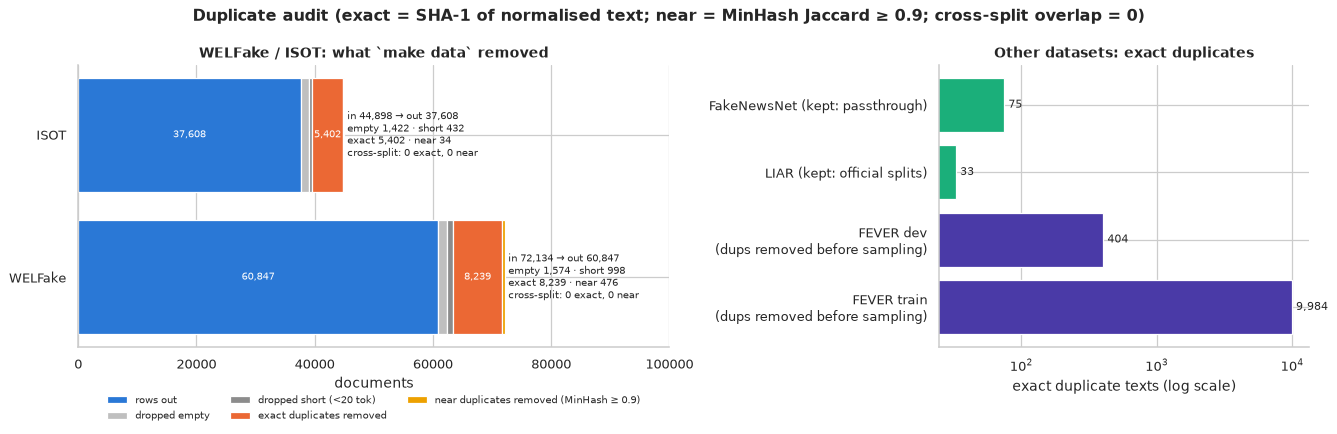

In [12]:
dup_rows = []
for d in C.DATASETS:
    s = summary[d]
    dup_rows.append({"dataset": d, "rows in": s["rows_in"], "dropped empty": s["dropped_empty"], "dropped short (<20 tok)": s["dropped_short"],
                     "exact duplicates removed": s["exact_dups_removed"], "near duplicates removed (MinHash ≥ 0.9)": s["near_dups_removed"],
                     "exact duplicates kept (official split / passthrough)": s.get("exact_dups_present_kept", 0), "rows out": s["rows_out"],
                     "cross-split exact (train-val / train-test)": (f"{s['cross_split_overlap']['exact_train_val']} / {s['cross_split_overlap']['exact_train_test']}" if "cross_split_overlap" in s else "n/a"),
                     "cross-split near (train-val / train-test)": (f"{s['cross_split_overlap']['near_train_val']} / {s['cross_split_overlap']['near_train_test']}" if "cross_split_overlap" in s else "n/a")})
dup_tab = pd.DataFrame(dup_rows).set_index("dataset")
display(dup_tab.T)

# live re-check: exact duplicate texts across splits in the processed parquet
live = {}
for d in ("welfake", "isot", "liar"):
    df = P[d]; h = pd.util.hash_pandas_object(df["text"].str.lower().str.strip(), index=False)
    by = {s: set(h[df["split"] == s]) for s in ("train", "val", "test")}
    live[d] = {"train∩val": len(by["train"] & by["val"]), "train∩test": len(by["train"] & by["test"]), "val∩test": len(by["val"] & by["test"])}
print("live re-check of exact duplicate texts across splits:", live)
NUM["dup"] = {d: {k: summary[d][k] for k in ("rows_in", "dropped_empty", "dropped_short", "exact_dups_removed", "near_dups_removed", "rows_out")} for d in ("welfake", "isot")}
NUM["dup"]["fever_subset"] = {"train_exact_dups_removed": summary["fever_subset"]["train_exact_dups_removed"], "val_exact_dups_removed": summary["fever_subset"]["val_exact_dups_removed"]}
NUM["dup"]["liar_kept"] = summary["liar"]["exact_dups_present_kept"]; NUM["dup"]["fnn_kept"] = summary["fnn_politifact"]["exact_dups_present_kept"]
NUM["dup"]["live_cross_split"] = live

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
parts = ["rows out", "dropped empty", "dropped short (<20 tok)", "exact duplicates removed", "near duplicates removed (MinHash ≥ 0.9)"]
cols = [CAT[0], "#bfbfbf", "#8c8c8c", CAT[1], CAT[3]]
left = np.zeros(2)
for p, c in zip(parts, cols):
    v = dup_tab.loc[["welfake", "isot"], p].to_numpy(dtype=float)
    ax.barh(["WELFake", "ISOT"], v, left=left, color=c, edgecolor="white", label=p)
    for i in range(2):
        if v[i] / dup_tab.loc[["welfake", "isot"], "rows in"].to_numpy()[i] > 0.06:
            ax.text(left[i] + v[i] / 2, i, f"{int(v[i]):,}", ha="center", va="center", fontsize=8, color="white")
    left += v
for i, d in enumerate(("welfake", "isot")):
    s = summary[d]
    ax.text(left[i] + 600, i, f"in {s['rows_in']:,} → out {s['rows_out']:,}\nempty {s['dropped_empty']:,} · short {s['dropped_short']:,}\nexact {s['exact_dups_removed']:,} · near {s['near_dups_removed']:,}\ncross-split: 0 exact, 0 near", va="center", fontsize=8)
ax.set_xlim(0, 100000); ax.set_xlabel("documents"); ax.set_title("WELFake / ISOT: what `make data` removed")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, fontsize=8)
ax = axes[1]
small = pd.Series({"FEVER train\n(dups removed before sampling)": summary["fever_subset"]["train_exact_dups_removed"],
                   "FEVER dev\n(dups removed before sampling)": summary["fever_subset"]["val_exact_dups_removed"],
                   "LIAR (kept: official splits)": summary["liar"]["exact_dups_present_kept"],
                   "FakeNewsNet (kept: passthrough)": summary["fnn_politifact"]["exact_dups_present_kept"]})
ax.barh(small.index, small.values, color=[CAT[6], CAT[6], CAT[2], CAT[2]], edgecolor="white")
for i, v in enumerate(small.values):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("exact duplicate texts (log scale)"); ax.set_title("Other datasets: exact duplicates")
fig.suptitle("Duplicate audit (exact = SHA-1 of normalised text; near = MinHash Jaccard ≥ 0.9; cross-split overlap = 0)", fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_duplicates"); plt.show()

## 9. Word clouds per class (WELFake, processed) → `eda_wordclouds.png`

Built from the full-corpus term frequencies computed in §6 (processed WELFake, stop words removed) — presentation aid only.

saved docs/figures/eda_wordclouds.png


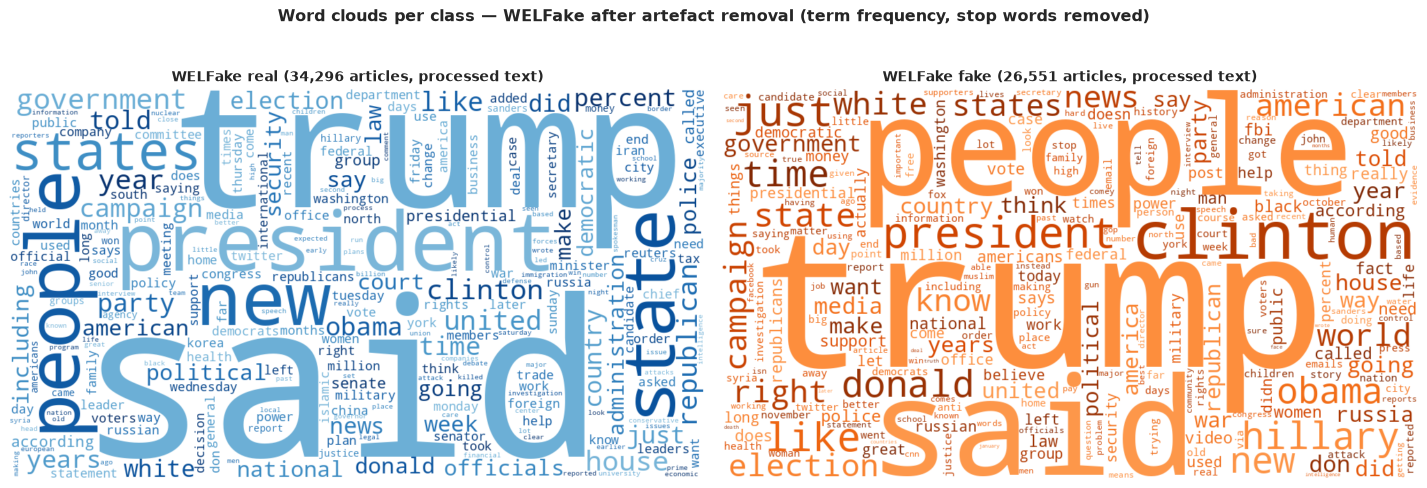

{'real': ['said', 'trump', 'president', 'people', 'new', 'state', 'states', 'government'], 'fake': ['trump', 'people', 'said', 'clinton', 'president', 'just', 'like', 'hillary']}


In [13]:
from wordcloud import WordCloud
wf = DF[("welfake", "proc")]
wf = wf[~wf.index.isin(STOP) & (wf.index.str.len() > 2) & ~wf.index.str.isnumeric()]
from matplotlib.colors import LinearSegmentedColormap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, lab, cmap in zip(axes, ("real", "fake"), ("Blues", "Oranges")):
    freqs = wf[f"tf_{lab}"].nlargest(250).to_dict()
    dark = LinearSegmentedColormap.from_list(cmap + "_dark", plt.get_cmap(cmap)(np.linspace(0.45, 1.0, 64)))   # drop the pale end
    wc = WordCloud(width=1000, height=560, background_color="white", colormap=dark, random_state=SEED, max_words=250, collocations=False).generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(f"WELFake {lab} ({P['welfake']['label'].eq(lab).sum():,} articles, processed text)")
fig.suptitle("Word clouds per class — WELFake after artefact removal (term frequency, stop words removed)", fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_wordclouds"); plt.show()
NUM["wc_top"] = {lab: list(wf[f"tf_{lab}"].nlargest(8).index) for lab in ("real", "fake")}
print(NUM["wc_top"])

## 10. Named-entity types per class (spaCy) → `eda_ner_types.png`

`en_core_web_sm` NER on **300 documents per class per dataset** (first 1,500 characters each, seed 42); counts are
normalised per 1,000 tokens so the two classes are comparable despite different lengths.

[ 174.4 s | peak RSS  2407 MB] NER welfake


[ 189.3 s | peak RSS  2410 MB] NER isot


PERSON    ORG    GPE   DATE   NORP  CARDINAL  TIME  ORDINAL   LOC  MONEY
dataset label                                                                          
isot    fake    27.34  20.19   9.85   9.76   7.15      5.34  1.24     1.08  0.53   0.89
        real    20.53  22.51  24.98  19.59  12.77      7.26  0.99     1.34  1.75   1.26
welfake fake    25.07  19.08  10.15  11.01   6.21      6.65  1.48     1.14  0.80   0.60
        real    23.36  18.90  20.73  16.41   9.89      6.68  1.20     1.32  1.28   1.03

share of documents with (PERSON|ORG|GPE) and (DATE|CARDINAL|PERCENT|MONEY) entities — claim-worthiness cue:


dataset  label
isot     fake     0.920
         real     1.000
welfake  fake     0.893
         real     0.983
Name: has_claim_cue, dtype: float64

saved docs/figures/eda_ner_types.png


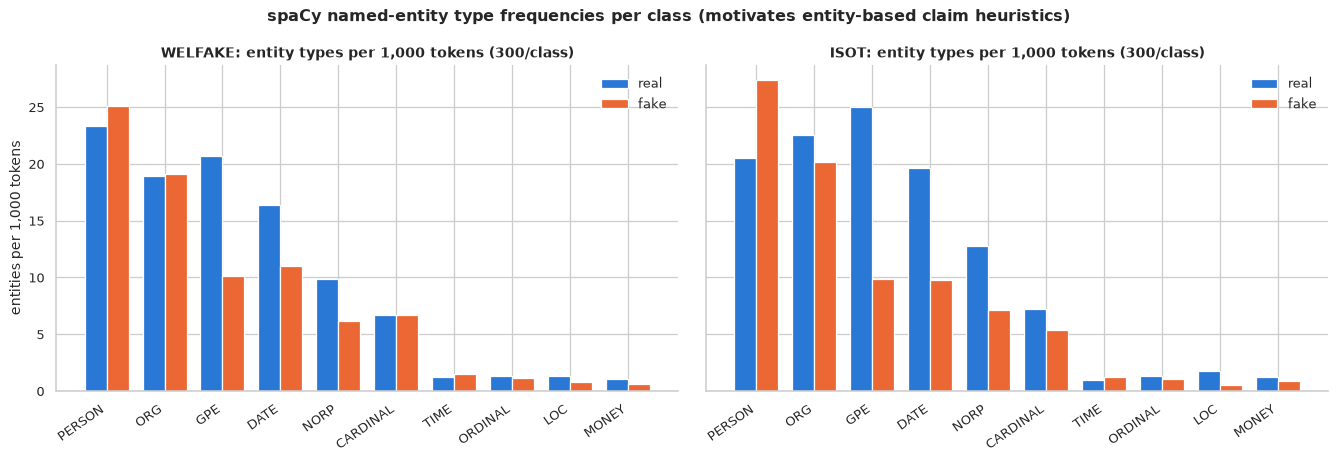

In [14]:
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer", "tagger", "attribute_ruler"])
N_NER = 300
ner_rows = []; claim_cues = {}
for d in ("welfake", "isot"):
    s = P[d].groupby("label", group_keys=False).apply(lambda g: g.sample(N_NER, random_state=SEED))
    docs = nlp.pipe((t[:1500] for t in s["text"]), batch_size=64)
    for lab, doc in zip(s["label"], docs):
        c = Counter(e.label_ for e in doc.ents)
        ner_rows.append({"dataset": d, "label": lab, "tokens": len(doc), **c,
                         "has_claim_cue": int(any(e.label_ in ("PERSON", "ORG", "GPE") for e in doc.ents) and any(e.label_ in ("DATE", "CARDINAL", "PERCENT", "MONEY") for e in doc.ents))})
    lap(f"NER {d}")
ner = pd.DataFrame(ner_rows).fillna(0)
ent_cols = [c for c in ner.columns if c.isupper()]
rate = ner.groupby(["dataset", "label"])[ent_cols].sum().div(ner.groupby(["dataset", "label"])["tokens"].sum(), axis=0) * 1000
top_types = rate.mean().nlargest(10).index.tolist()
display(rate[top_types].round(2))
cue = ner.groupby(["dataset", "label"])["has_claim_cue"].mean()
print("share of documents with (PERSON|ORG|GPE) and (DATE|CARDINAL|PERCENT|MONEY) entities — claim-worthiness cue:"); display(cue.round(3))
NUM["ner_rate"] = rate[top_types].round(2).to_dict("index"); NUM["ner_claim_cue"] = cue.round(3).to_dict()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)
for ax, d in zip(axes, ("welfake", "isot")):
    r = rate.loc[d, top_types].T
    x = np.arange(len(top_types)); wd = 0.38
    ax.bar(x - wd / 2, r["real"], wd, color=PAL["real"], label="real", edgecolor="white")
    ax.bar(x + wd / 2, r["fake"], wd, color=PAL["fake"], label="fake", edgecolor="white")
    ax.set_xticks(x, top_types, rotation=35, ha="right"); ax.set_title(f"{d.upper()}: entity types per 1,000 tokens ({N_NER}/class)")
    ax.legend()
axes[0].set_ylabel("entities per 1,000 tokens")
fig.suptitle("spaCy named-entity type frequencies per class (motivates entity-based claim heuristics)", fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_ner_types"); plt.show()

## 11. ISOT publication dates → `eda_isot_dates.png`

ISOT is the only dataset with a date column (WELFake has none). Monthly article counts per class from the processed parquet.

raw ISOT rows with an unparseable date: 10 of 44,898; processed rows with a date: 37,607 / 37,608


,min,max,count
label,,,
fake,2015-03-31,2018-02-19,16702
real,2016-01-13,2017-12-31,20905


label,fake,real
dt,,
2015.0,1518,0
2016.0,8807,4689
2017.0,6342,16216
2018.0,35,0


saved docs/figures/eda_isot_dates.png


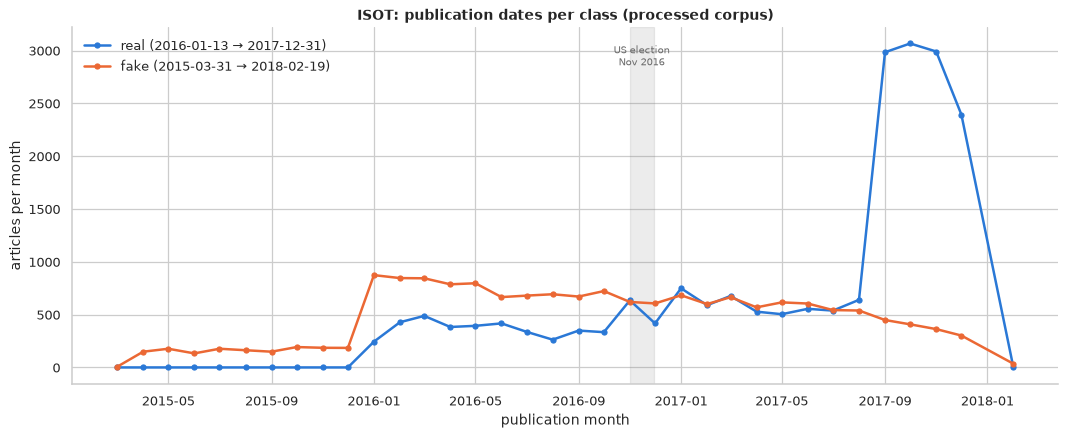

In [15]:
iso = P["isot"].copy(); iso["dt"] = pd.to_datetime(iso["date"], errors="coerce")
print(f"raw ISOT rows with an unparseable date: {ISOT_RAW_DATE_NA} of {summary['isot']['rows_in']:,}; processed rows with a date: {iso['dt'].notna().sum():,} / {len(iso):,}")
rng_tab = iso.groupby("label")["dt"].agg(["min", "max", "count"]); display(rng_tab)
monthly = iso.dropna(subset=["dt"]).groupby([iso["dt"].dt.to_period("M"), "label"]).size().unstack(fill_value=0)
yearly = pd.crosstab(iso["dt"].dt.year, iso["label"]); display(yearly)
NUM["isot_dates"] = {lab: (str(rng_tab.loc[lab, "min"].date()), str(rng_tab.loc[lab, "max"].date())) for lab in ("real", "fake")}
NUM["isot_year_share"] = yearly.div(yearly.sum()).round(3).to_dict()
NUM["isot_median_date"] = {lab: str(iso.loc[iso.label == lab, "dt"].median().date()) for lab in ("real", "fake")}

fig, ax = plt.subplots(figsize=(12, 5))
for lab in ("real", "fake"):
    ax.plot(monthly.index.to_timestamp(), monthly[lab], color=PAL[lab], lw=2, marker="o", ms=4, label=f"{lab} ({rng_tab.loc[lab, 'min'].date()} → {rng_tab.loc[lab, 'max'].date()})")
ax.axvspan(pd.Timestamp("2016-11-01"), pd.Timestamp("2016-11-30"), color="grey", alpha=0.15); ax.text(pd.Timestamp("2016-11-15"), ax.get_ylim()[1] * 0.95, "US election\nNov 2016", ha="center", va="top", fontsize=8, color="dimgrey")
ax.set_xlabel("publication month"); ax.set_ylabel("articles per month"); ax.set_title("ISOT: publication dates per class (processed corpus)")
ax.legend(loc="upper left"); fig.tight_layout(); savefig(fig, "eda_isot_dates"); plt.show()

## 12. LIAR: label distributions, label vs. party → `eda_liar_labels.png`; speakers and subjects → `eda_liar_speakers.png`

statement length (words): {'count': 12836.0, 'mean': 17.9, 'std': 7.7, 'min': 2.0, '50%': 17.0, '95%': 32.0, 'max': 66.0}


label,pants-fire,false,barely-true,half-true,mostly-true,true
party,,,,,,
republican,8.1,22.9,18.7,20.0,16.0,14.3
democrat,4.5,15.3,14.1,22.5,24.1,19.5
none,16.1,19.3,15.1,17.9,17.4,14.2
organization,8.3,22.3,21.1,26.4,10.9,10.9
independent,2.2,12.6,14.8,17.0,36.8,16.5


saved docs/figures/eda_liar_labels.png


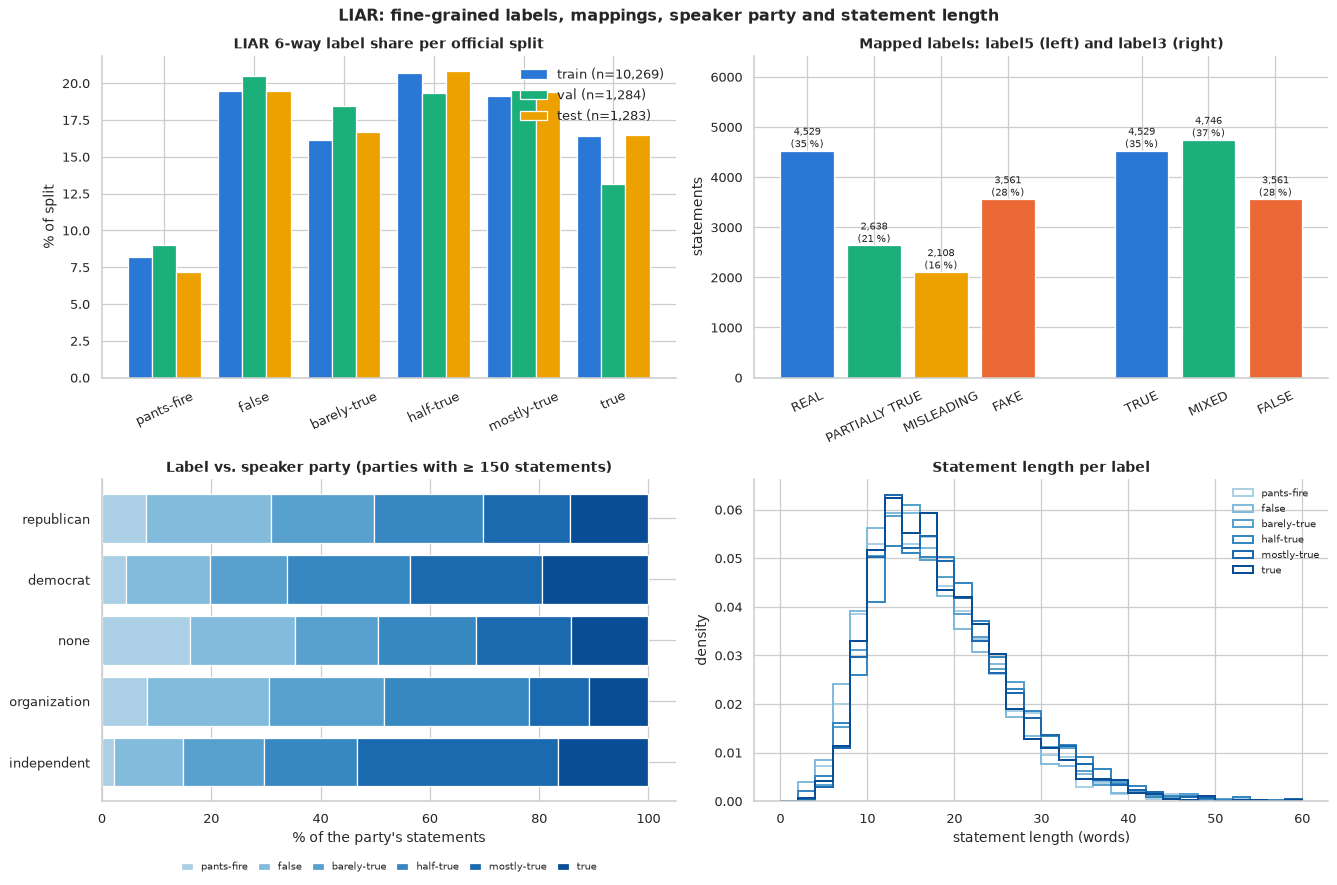

In [16]:
liar = P["liar"].copy()
meta = pd.DataFrame(liar["meta"].map(json.loads).tolist(), index=liar.index)
liar = pd.concat([liar, meta[["subject", "speaker", "party", "context"]]], axis=1)
liar["n_words"] = liar["text"].str.count(r"\S+")
party_top = liar["party"].replace("", "unknown").value_counts()
parties = [p for p in party_top.index if party_top[p] >= 150]
pt = pd.crosstab(liar["party"].replace("", "unknown"), liar["label"], normalize="index").reindex(parties)[LIAR_ORDER]
print("statement length (words):", liar["n_words"].describe(percentiles=[.5, .95]).round(1).to_dict())
display((pt * 100).round(1))
NUM["liar_party_false_share"] = {p: round(float(pt.loc[p, ["pants-fire", "false"]].sum()), 3) for p in parties}
NUM["liar_words_median"] = float(liar["n_words"].median()); NUM["liar_words_p95"] = float(liar["n_words"].quantile(0.95))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ax = axes[0, 0]
for i, s in enumerate(("train", "val", "test")):
    v = liar.loc[liar.split == s, "label"].value_counts(normalize=True).reindex(LIAR_ORDER)
    ax.bar(np.arange(6) + (i - 1) * 0.27, v.values * 100, 0.27, color=[CAT[0], CAT[2], CAT[3]][i], label=f"{s} (n={int((liar.split == s).sum()):,})", edgecolor="white")
ax.set_xticks(np.arange(6), LIAR_ORDER, rotation=25); ax.set_ylabel("% of split"); ax.set_title("LIAR 6-way label share per official split"); ax.legend()
ax = axes[0, 1]
for k, (col, order, colors) in enumerate((("label5", L5_ORDER, [CAT[0], CAT[2], CAT[3], CAT[1]]), ("label3", L3_ORDER, [CAT[0], CAT[2], CAT[1]]))):
    v = liar[col].value_counts().reindex(order)
    ax.bar(np.arange(len(order)) + k * 5, v.values, color=colors, edgecolor="white")
    for i, val in enumerate(v.values):
        ax.text(i + k * 5, val, f"{val:,}\n({100 * val / len(liar):.0f} %)", ha="center", va="bottom", fontsize=8)
ax.set_xticks(list(range(4)) + [5, 6, 7], L5_ORDER + L3_ORDER, rotation=25); ax.set_ylabel("statements"); ax.set_title("Mapped labels: label5 (left) and label3 (right)")
ax.set_ylim(0, len(liar) * 0.5)
ax = axes[1, 0]
bottom = np.zeros(len(parties))
for lab, col in zip(LIAR_ORDER, cols_liar):
    ax.barh(parties, pt[lab].values * 100, left=bottom, color=col, edgecolor="white", label=lab); bottom += pt[lab].values * 100
ax.set_xlabel("% of the party's statements"); ax.set_title("Label vs. speaker party (parties with ≥ 150 statements)")
ax.legend(ncol=6, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16), handlelength=1.2, columnspacing=1.0)
ax.invert_yaxis()
ax = axes[1, 1]
for lab, col in zip(LIAR_ORDER, cols_liar):
    ax.hist(liar.loc[liar.label == lab, "n_words"].clip(upper=60), bins=np.arange(0, 62, 2), histtype="step", lw=1.6, color=col, label=lab, density=True)
ax.set_xlabel("statement length (words)"); ax.set_ylabel("density"); ax.set_title("Statement length per label"); ax.legend(fontsize=8)
fig.suptitle("LIAR: fine-grained labels, mappings, speaker party and statement length", fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_liar_labels"); plt.show()

3,318 distinct speakers; the top-10 speak 19.5 % of statements


saved docs/figures/eda_liar_speakers.png


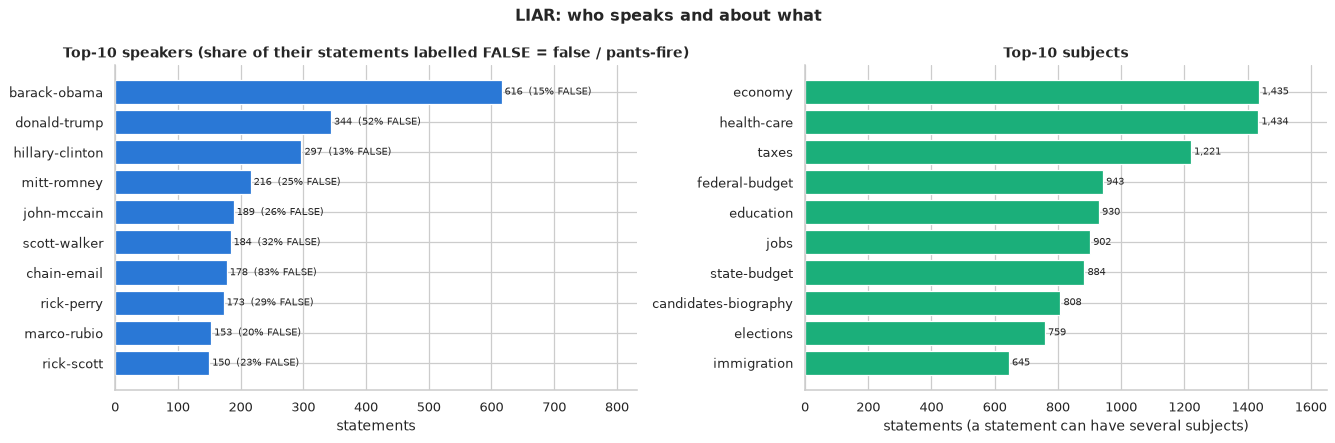

In [17]:
subjects = liar["subject"].str.split(",").explode().str.strip()
top_speakers = liar["speaker"].value_counts().head(10); top_subjects = subjects.value_counts().head(10)
spk_false = liar.groupby("speaker")["label3"].apply(lambda s: (s == "FALSE").mean()).reindex(top_speakers.index)
NUM["liar_top_speakers"] = top_speakers.to_dict(); NUM["liar_top_subjects"] = top_subjects.to_dict()
NUM["liar_top_speaker_share"] = float(top_speakers.sum() / len(liar)); NUM["liar_n_speakers"] = int(liar["speaker"].nunique())
NUM["liar_speaker_false_share"] = spk_false.round(2).to_dict()
print(f"{NUM['liar_n_speakers']:,} distinct speakers; the top-10 speak {pct(NUM['liar_top_speaker_share'])} of statements")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.barh(top_speakers.index[::-1], top_speakers.values[::-1], color=CAT[0], edgecolor="white")
for i, (n, f) in enumerate(zip(top_speakers.values[::-1], spk_false.values[::-1])):
    ax.text(n, i, f" {n:,}  ({f:.0%} FALSE)", va="center", fontsize=8)
ax.set_xlabel("statements"); ax.set_title("Top-10 speakers (share of their statements labelled FALSE = false / pants-fire)"); ax.set_xlim(0, top_speakers.max() * 1.35)
ax = axes[1]
ax.barh(top_subjects.index[::-1], top_subjects.values[::-1], color=CAT[2], edgecolor="white")
for i, n in enumerate(top_subjects.values[::-1]):
    ax.text(n, i, f" {n:,}", va="center", fontsize=8)
ax.set_xlabel("statements (a statement can have several subjects)"); ax.set_title("Top-10 subjects"); ax.set_xlim(0, top_subjects.max() * 1.15)
fig.suptitle("LIAR: who speaks and about what", fontsize=13, fontweight="bold"); fig.tight_layout(); savefig(fig, "eda_liar_speakers"); plt.show()

## 13. FEVER subset: label balance, claim length, evidence per claim → `eda_fever_balance.png`

The parquet keeps the claim, the label and the evidence *pointers* (Wikipedia page + sentence id); the evidence
sentences themselves are fetched at index-build time, so "evidence sentence length" here is approximated by the
number of evidence pointers per claim and by the claim length.

split,train,val
label,,
SUPPORTS,6666,1000
REFUTES,6667,1000
NEUTRAL,6667,1000


,n_words median,n_words mean,n_words <lambda_0>,n_evidence_pages median,n_evidence_pages mean,n_evidence_pages <lambda_0>,n_evidence_sents median,n_evidence_sents mean,n_evidence_sents <lambda_0>
label,,,,,,,,,
NEUTRAL,8.0,8.19,14.0,0.0,0.00,0.0,0.0,0.00,0.0
REFUTES,8.0,8.24,13.0,1.0,1.23,2.0,1.0,1.87,6.0
SUPPORTS,8.0,8.24,14.0,1.0,1.28,2.0,1.0,1.79,5.0


saved docs/figures/eda_fever_balance.png


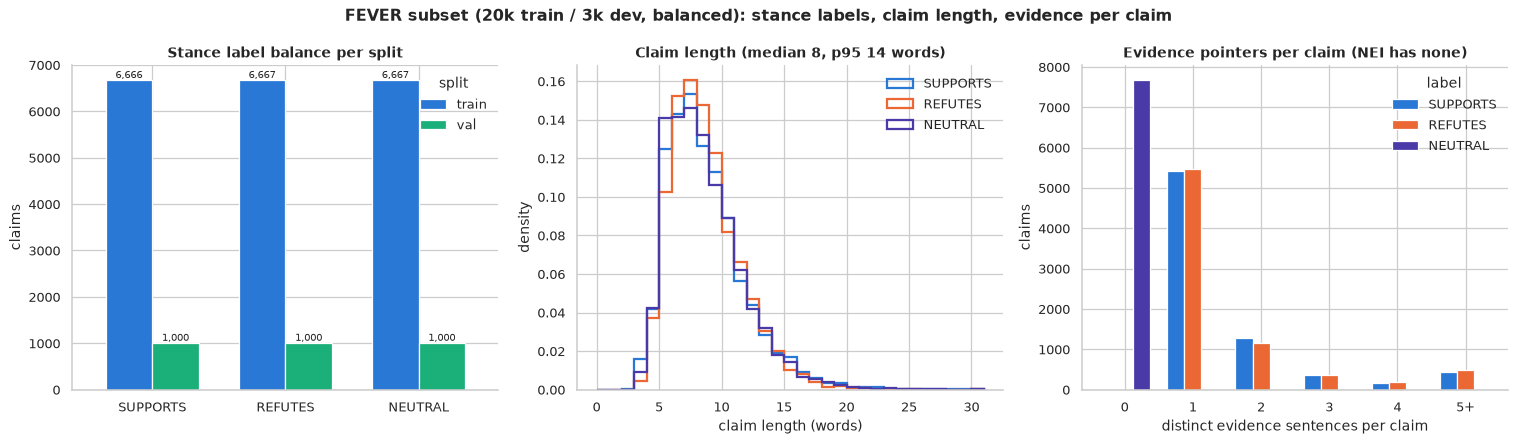

In [18]:
fev = P["fever_subset"].copy()
fm = fev["meta"].map(json.loads)
fev["n_words"] = fev["text"].str.count(r"\S+")
fev["n_evidence_pages"] = fm.map(lambda m: len(m.get("evidence_pages", [])))
fev["n_evidence_sents"] = fm.map(lambda m: len({tuple(e) for e in m.get("evidence", [])}))
fb = pd.crosstab(fev["label"], fev["split"]).reindex(["SUPPORTS", "REFUTES", "NEUTRAL"]); display(fb)
ev = fev.groupby("label")[["n_words", "n_evidence_pages", "n_evidence_sents"]].agg(["median", "mean", lambda s: s.quantile(0.95)]).round(2)
ev.columns = [f"{a} {b if isinstance(b, str) else 'p95'}" for a, b in ev.columns]; display(ev)
NUM["fever_balance"] = fb.to_dict(); NUM["fever_words_median"] = float(fev["n_words"].median()); NUM["fever_words_p95"] = float(fev["n_words"].quantile(0.95))
NUM["fever_multi_evidence_share"] = float((fev.loc[fev.label != "NEUTRAL", "n_evidence_sents"] > 1).mean())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ax = axes[0]
fb.plot.bar(ax=ax, color=[CAT[0], CAT[2]], edgecolor="white", width=0.7); ax.set_title("Stance label balance per split"); ax.set_ylabel("claims"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom", fontsize=8)
ax = axes[1]
for lab, col in zip(["SUPPORTS", "REFUTES", "NEUTRAL"], [CAT[0], CAT[1], CAT[6]]):
    ax.hist(fev.loc[fev.label == lab, "n_words"].clip(upper=30), bins=np.arange(0, 32, 1), histtype="step", lw=1.8, color=col, label=lab, density=True)
ax.set_xlabel("claim length (words)"); ax.set_ylabel("density"); ax.set_title(f"Claim length (median {NUM['fever_words_median']:.0f}, p95 {NUM['fever_words_p95']:.0f} words)"); ax.legend()
ax = axes[2]
vc = pd.crosstab(fev["n_evidence_sents"].clip(upper=5), fev["label"])[["SUPPORTS", "REFUTES", "NEUTRAL"]]
vc.plot.bar(ax=ax, color=[CAT[0], CAT[1], CAT[6]], edgecolor="white", width=0.75); ax.set_xticklabels(["0", "1", "2", "3", "4", "5+"], rotation=0)
ax.set_xlabel("distinct evidence sentences per claim"); ax.set_ylabel("claims"); ax.set_title("Evidence pointers per claim (NEI has none)")
fig.suptitle("FEVER subset (20k train / 3k dev, balanced): stance labels, claim length, evidence per claim", fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_fever_balance"); plt.show()

## 14. Style features per class → `eda_style_features.png`

Sample of **5,000 documents per class per dataset** (seed 42, processed text): exclamation and question marks per
1,000 characters, share of ALL-CAPS words (≥ 3 letters), mean sentence length, a Flesch reading-ease estimate (syllables ≈
vowel groups) and the share of titles that are ≥ 50 % ALL-CAPS words. Bars = mean, whiskers = 95 % CI.

exclamations / 1k chars  question marks / 1k chars  ALL-CAPS words (%)  mean sentence length (words)  Flesch reading ease (est.)  title ≥50% CAPS (%)
dataset label                                                                                                                                                       
isot    fake                      0.47                       0.54                1.20                         30.63                       36.85                 5.26
        real                      0.03                       0.03                0.54                         23.23                       34.27                 0.00
welfake fake                      0.44                       0.51                1.24                         28.22                       39.02                 4.18
        real                      0.04                       0.11                0.49                         21.48                       39.28                 0.00

[ 198.2 s | peak RSS  2438 MB] style features


saved docs/figures/eda_style_features.png


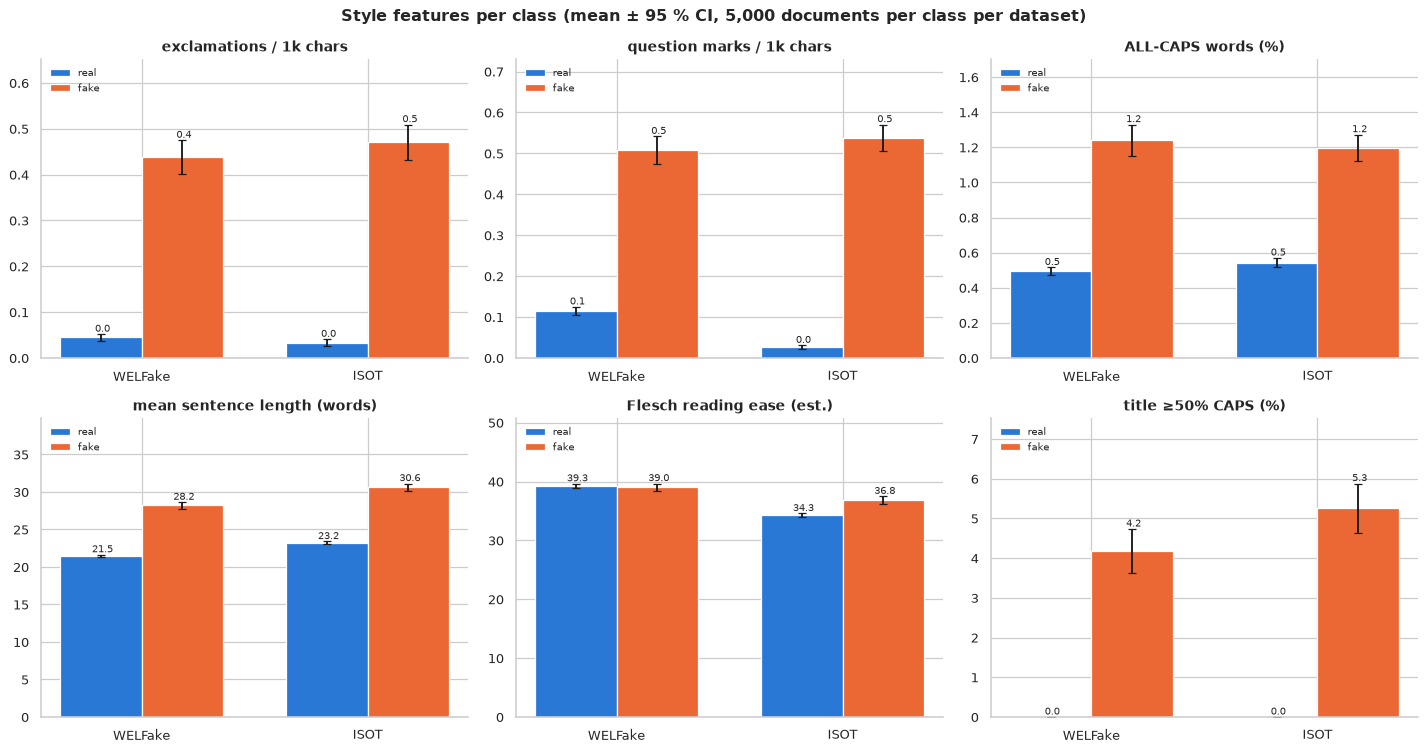

In [19]:
N_STY = 5000
def style_features(df):
    t = df["text"]; chars = t.str.len().clip(lower=1); words = df["n_words"].clip(lower=1)
    sents = t.str.count(r"[.!?]+(?:\s|$)").clip(lower=1)
    syll = t.str.lower().str.count(r"[aeiouy]+")
    out = pd.DataFrame({"label": df["label"].to_numpy(), "dataset": df["source_dataset"].to_numpy(),
                        "exclamations / 1k chars": (t.str.count("!") / chars * 1000).to_numpy(),
                        "question marks / 1k chars": (t.str.count(r"\?") / chars * 1000).to_numpy(),
                        "ALL-CAPS words (%)": (t.str.count(r"\b[A-Z]{3,}\b") / words * 100).to_numpy(),
                        "mean sentence length (words)": (words / sents).to_numpy(),
                        "Flesch reading ease (est.)": (206.835 - 1.015 * (words / sents) - 84.6 * (syll / words)).to_numpy(),
                        "title ≥50% CAPS (%)": (df["title"].str.count(r"\b[A-Z]{3,}\b") / df["n_title_words"].clip(lower=1) >= 0.5).astype(float).to_numpy() * 100})
    return out
sty = pd.concat([style_features(P[d].groupby("label", group_keys=False).apply(lambda g: g.sample(N_STY, random_state=SEED))) for d in ("welfake", "isot")])
feat_cols = [c for c in sty.columns if c not in ("label", "dataset")]
agg = sty.groupby(["dataset", "label"])[feat_cols].agg(["mean", "sem"])
means = agg.xs("mean", axis=1, level=1).round(2); display(means)
NUM["style"] = means.to_dict("index")
lap("style features")

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for ax, f in zip(axes.ravel(), feat_cols):
    x = np.arange(2); wd = 0.36
    for k, lab in enumerate(("real", "fake")):
        m = [agg.loc[(d, lab), (f, "mean")] for d in ("welfake", "isot")]; e = [1.96 * agg.loc[(d, lab), (f, "sem")] for d in ("welfake", "isot")]
        ax.bar(x + (k - 0.5) * wd, m, wd, yerr=e, capsize=3, color=PAL[lab], edgecolor="white", label=lab)
        for xi, mi, ei in zip(x + (k - 0.5) * wd, m, e):
            ax.text(xi, mi + ei, f" {mi:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x, ["WELFake", "ISOT"]); ax.set_title(f); ax.set_ylim(0, ax.get_ylim()[1] * 1.22); ax.legend(fontsize=8, loc="upper left")
fig.suptitle(f"Style features per class (mean ± 95 % CI, {N_STY:,} documents per class per dataset)", fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_style_features"); plt.show()

## 15. Vocabulary overlap and OOV between WELFake and ISOT → `eda_vocab_overlap.png`

First we check how many **articles** the two corpora literally share (WELFake was assembled from Kaggle, McIntire, Reuters and
BuzzFeed sources — the Kaggle/Reuters part *is* ISOT). Then vocabulary overlap / OOV are computed twice: full WELFake vs ISOT,
and the honest version **WELFake-only (rows not in ISOT) vs ISOT**. *Vocabulary* = unigrams with document frequency ≥ 2
(processed text, from the §6 term/document frequencies); *OOV rate* = share of one corpus's token occurrences whose type is
absent from the other corpus's vocabulary; *class-cue transfer* = correlation of the per-word log-odds (real vs fake) across corpora.

processed ISOT articles with byte-identical text in WELFake: 37,450 (99.6 % of ISOT); identical titles: 37,586
WELFake rows also in ISOT: 37,450 (61.5 % of WELFake) | WELFake-only remainder: 23,397 rows, labels {'real': 13534, 'fake': 9863}


[ 209.1 s | peak RSS  2469 MB] doc-freq WELFake-only



welfake vs ISOT — vocabulary 106,426 vs 58,053, intersection 58,052; Jaccard {'top-5,000': 0.86, 'top-20,000': 0.807, 'all (df ≥ 2)': 0.545}
  OOV (token occurrences): ISOT→welfake 0.00 % | welfake→ISOT 0.98 %
  class log-odds of shared words (df ≥ 100 in both): r = 0.91, same sign 79.7 %, 100 % of the 50 most fake-leaning words also lean fake in ISOT

welfake_only vs ISOT — vocabulary 89,221 vs 58,053, intersection 46,521; Jaccard {'top-5,000': 0.753, 'top-20,000': 0.693, 'all (df ≥ 2)': 0.462}
  OOV (token occurrences): ISOT→welfake_only 0.50 % | welfake_only→ISOT 1.64 %
  class log-odds of shared words (df ≥ 100 in both): r = 0.28, same sign 54.9 %, 74 % of the 50 most fake-leaning words also lean fake in ISOT


saved docs/figures/eda_vocab_overlap.png


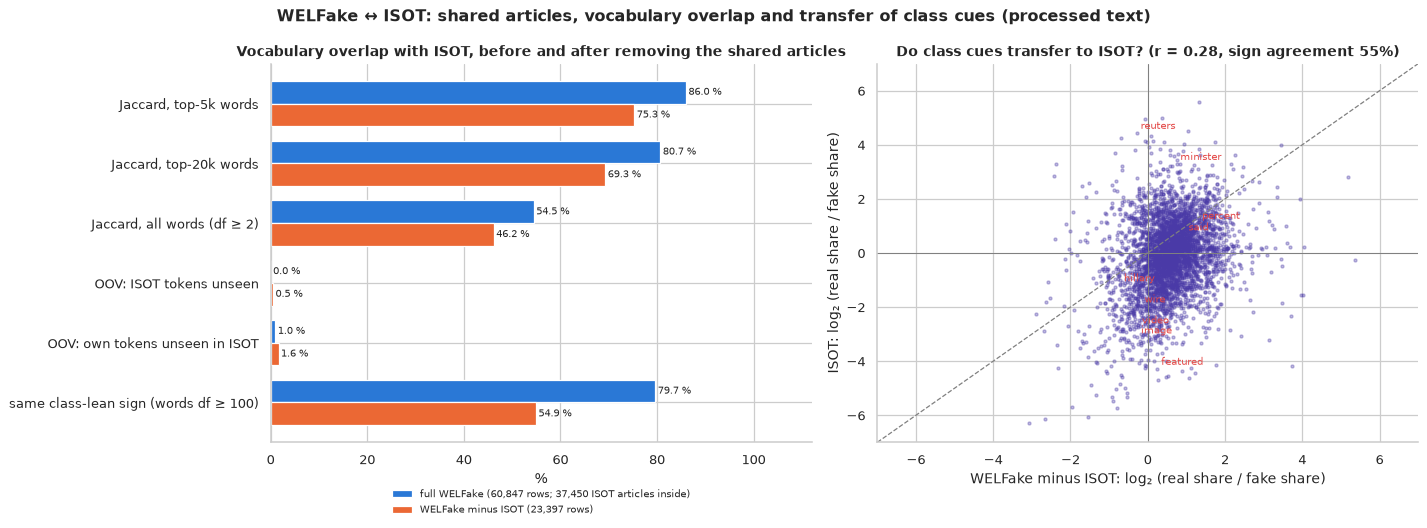

In [20]:
# 1) how many articles do the two corpora literally share?  (WELFake = Kaggle + McIntire + Reuters + BuzzFeed; "Kaggle/Reuters" is ISOT)
hw = pd.util.hash_pandas_object(P["welfake"]["text"].str.lower().str.strip(), index=False)
hi = pd.util.hash_pandas_object(P["isot"]["text"].str.lower().str.strip(), index=False)
shared_docs = int(hi.isin(set(hw)).sum())
in_isot = hw.isin(set(hi)).to_numpy()                       # WELFake rows whose text also exists in ISOT
tw = set(P["welfake"]["title"].str.lower().str.strip()) - {""}; shared_titles = int(P["isot"]["title"].str.lower().str.strip().isin(tw).sum())
wonly = P["welfake"][~in_isot]
print(f"processed ISOT articles with byte-identical text in WELFake: {shared_docs:,} ({pct(shared_docs / len(P['isot']))} of ISOT); identical titles: {shared_titles:,}")
print(f"WELFake rows also in ISOT: {int(in_isot.sum()):,} ({pct(in_isot.mean())} of WELFake) | WELFake-only remainder: {len(wonly):,} rows, labels {wonly['label'].value_counts().to_dict()}")

# 2) vocabulary overlap / OOV — full WELFake vs ISOT, and the honest version: WELFake-ONLY (non-ISOT rows) vs ISOT
DF[("welfake_only", "proc")] = add_ratio(class_doc_freq(wonly["text"], wonly["label"], min_df=2)); lap("doc-freq WELFake-only")
def overlap_stats(a_name, b_name):
    va, vb = DF[(a_name, "proc")], DF[(b_name, "proc")]
    tf_a = va["tf_real"] + va["tf_fake"]; tf_b = vb["tf_real"] + vb["tf_fake"]
    vocab_a, vocab_b = set(va.index), set(vb.index)
    jacc = {}
    for k in (5000, 20000, None):
        A = set(tf_a.nlargest(k).index) if k else vocab_a; B = set(tf_b.nlargest(k).index) if k else vocab_b
        jacc[f"top-{k:,}" if k else "all (df ≥ 2)"] = len(A & B) / len(A | B)
    both = pd.DataFrame({"a": va["log2_ratio"], "b": vb["log2_ratio"], "df_a": va["docs_real"] + va["docs_fake"], "df_b": vb["docs_real"] + vb["docs_fake"]}).dropna()
    both = both[(both.df_a >= 100) & (both.df_b >= 100)]
    return {"size_a": len(vocab_a), "size_b": len(vocab_b), "intersection": len(vocab_a & vocab_b), "jaccard": {k: round(v, 3) for k, v in jacc.items()},
            "oov_b_in_a": float(tf_b[~tf_b.index.isin(vocab_a)].sum() / tf_b.sum()), "oov_a_in_b": float(tf_a[~tf_a.index.isin(vocab_b)].sum() / tf_a.sum()),
            "logodds_corr": float(np.corrcoef(both["a"], both["b"])[0, 1]), "sign_agreement": float((np.sign(both["a"]) == np.sign(both["b"])).mean()),
            "top50_fake_transfer": float((both.nsmallest(50, "a")["b"] < 0).mean()), "_both": both}
OV = {"welfake": overlap_stats("welfake", "isot"), "welfake_only": overlap_stats("welfake_only", "isot")}
for name, o in OV.items():
    print(f"\n{name} vs ISOT — vocabulary {o['size_a']:,} vs {o['size_b']:,}, intersection {o['intersection']:,}; Jaccard {o['jaccard']}")
    print(f"  OOV (token occurrences): ISOT→{name} {pct(o['oov_b_in_a'], 2)} | {name}→ISOT {pct(o['oov_a_in_b'], 2)}")
    print(f"  class log-odds of shared words (df ≥ 100 in both): r = {o['logodds_corr']:.2f}, same sign {pct(o['sign_agreement'])}, "
          f"{pct(o['top50_fake_transfer'], 0)} of the 50 most fake-leaning words also lean fake in ISOT")
NUM["vocab"] = {k: {kk: vv for kk, vv in o.items() if kk != "_both"} for k, o in OV.items()}
NUM["vocab"]["shared_exact_articles"] = shared_docs; NUM["vocab"]["shared_exact_titles"] = shared_titles
NUM["vocab"]["welfake_rows_in_isot"] = int(in_isot.sum()); NUM["vocab"]["welfake_only_rows"] = len(wonly); NUM["vocab"]["welfake_only_labels"] = wonly["label"].value_counts().to_dict()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
metrics = ["Jaccard, top-5k words", "Jaccard, top-20k words", "Jaccard, all words (df ≥ 2)", "OOV: ISOT tokens unseen", "OOV: own tokens unseen in ISOT",
           "same class-lean sign (words df ≥ 100)"]
def vals(o):
    return [o["jaccard"]["top-5,000"], o["jaccard"]["top-20,000"], o["jaccard"]["all (df ≥ 2)"], o["oov_b_in_a"], o["oov_a_in_b"], o["sign_agreement"]]
y = np.arange(len(metrics)); h = 0.38
for k, (name, col, lab) in enumerate((("welfake", CAT[0], f"full WELFake ({len(P['welfake']):,} rows; {shared_docs:,} ISOT articles inside)"),
                                       ("welfake_only", CAT[1], f"WELFake minus ISOT ({len(wonly):,} rows)"))):
    v = np.array(vals(OV[name])) * 100
    ax.barh(y + (k - 0.5) * h, v, h, color=col, edgecolor="white", label=lab)
    for yi, vi_ in zip(y + (k - 0.5) * h, v):
        ax.text(vi_ + 0.5, yi, f"{vi_:.1f} %", va="center", fontsize=8)
ax.set_yticks(y, metrics); ax.invert_yaxis(); ax.set_xlim(0, 112); ax.set_xlabel("%"); ax.set_title("Vocabulary overlap with ISOT, before and after removing the shared articles")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=1, fontsize=8)
ax = axes[1]
both = OV["welfake_only"]["_both"]
smp = both.sample(min(4000, len(both)), random_state=SEED)
ax.scatter(smp["a"], smp["b"], s=6, alpha=0.35, color=CAT[6])
lim = 7; ax.plot([-lim, lim], [-lim, lim], color="grey", ls="--", lw=1); ax.axhline(0, color="grey", lw=0.8); ax.axvline(0, color="grey", lw=0.8)
for tkn in ["reuters", "said", "video", "image", "hillary", "getty", "wire", "featured", "percent", "minister"]:
    if tkn in both.index:
        ax.annotate(tkn, (both.loc[tkn, "a"], both.loc[tkn, "b"]), fontsize=8, color=HILITE, xytext=(3, 3), textcoords="offset points")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("WELFake minus ISOT: log₂ (real share / fake share)"); ax.set_ylabel("ISOT: log₂ (real share / fake share)")
o = OV["welfake_only"]; ax.set_title(f"Do class cues transfer to ISOT? (r = {o['logodds_corr']:.2f}, sign agreement {o['sign_agreement']:.0%})")
fig.suptitle("WELFake ↔ ISOT: shared articles, vocabulary overlap and transfer of class cues (processed text)", fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "eda_vocab_overlap"); plt.show()

## 16. Sources / domains → `eda_sources.png`

ISOT ships a `subject` column (kept in `meta`); FakeNewsNet PolitiFact ships the article URL, from which we take the domain.

,fake,real
subject,,
politicsNews,0,11272
worldnews,0,10145
News,9050,0
politics,6841,0
left-news,4459,0
Government News,1570,0
US_News,783,0
Middle-east,778,0


ISOT: 100% of subjects belong to exactly one class (the subject is metadata, never fed to the models); FakeNewsNet: 404 distinct domains, 61 rows without a URL


saved docs/figures/eda_sources.png


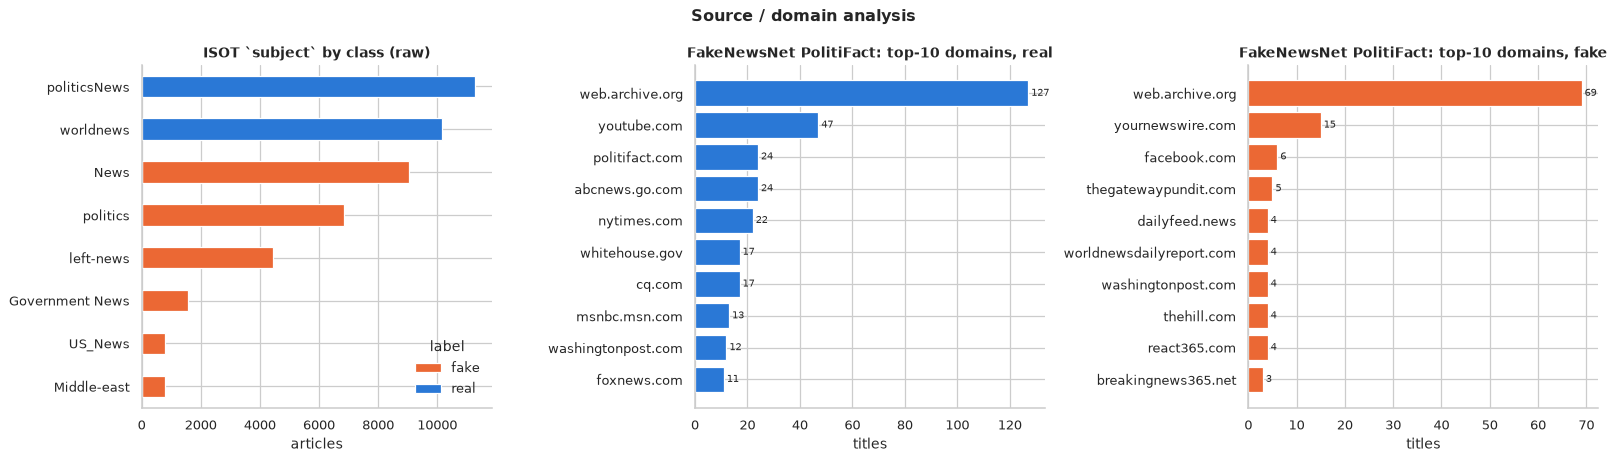

In [21]:
isub = ISOT_SUBJECT_X.copy(); isub.index.name = "subject"; display(isub)
pure = float((isub.min(axis=1) == 0).mean())
fnn = P["fnn_politifact"].copy(); fnn["domain"] = fnn["meta"].map(lambda m: json.loads(m).get("news_url", "")).str.lower().str.replace(r"^https?://", "", regex=True).str.replace(r"^www\.", "", regex=True).str.split("/").str[0]
dom = {lab: fnn.loc[(fnn.label == lab) & (fnn.domain != ""), "domain"].value_counts().head(10) for lab in ("real", "fake")}
NUM["sources"] = {"isot_subjects_single_class": pure, "isot_subjects": isub.to_dict(), "fnn_top_domains": {lab: dom[lab].to_dict() for lab in dom},
                  "fnn_domains_unique": int(fnn["domain"].nunique()), "fnn_missing_url": int((fnn.domain == "").sum())}
print(f"ISOT: {pure:.0%} of subjects belong to exactly one class (the subject is metadata, never fed to the models); "
      f"FakeNewsNet: {fnn['domain'].nunique():,} distinct domains, {int((fnn.domain == '').sum())} rows without a URL")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
ax = axes[0]
isub.loc[isub.sum(axis=1).sort_values().index].plot.barh(ax=ax, stacked=True, color=[PAL["fake"], PAL["real"]], edgecolor="white")
ax.set_xlabel("articles"); ax.set_ylabel(""); ax.set_title("ISOT `subject` by class (raw)"); ax.legend(title="label")
for ax, lab in zip(axes[1:], ("real", "fake")):
    s = dom[lab][::-1]; ax.barh(s.index, s.values, color=PAL[lab], edgecolor="white")
    for i, v in enumerate(s.values):
        ax.text(v, i, f" {v}", va="center", fontsize=8)
    ax.set_xlabel("titles"); ax.set_title(f"FakeNewsNet PolitiFact: top-10 domains, {lab}")
fig.suptitle("Source / domain analysis", fontsize=13, fontweight="bold"); fig.tight_layout(); savefig(fig, "eda_sources"); plt.show()

## 17. Summary: figures written, runtime, `docs/eda_summary.md`

The last cell regenerates `docs/eda_summary.md` from the numbers collected above (`NUM`), so the insight lines always match
the figures on disk.

In [22]:
runtime = time.time() - T0
NUM["runtime_s"] = round(runtime, 1)
figs = sorted(FIG.glob("eda_*.png"))
print(f"{len(figs)} figures in {FIG.relative_to(ROOT)} (≥ 10 required); notebook runtime {runtime / 60:.1f} min")
for f in figs:
    print(f"  {f.name:32s} {f.stat().st_size / 1024:7.0f} KB")
assert set(SAVED) == {f.stem for f in figs}, "stale figure(s) in docs/figures — delete eda_*.png and rerun"
def jsonable(o):
    if isinstance(o, dict):
        return {(" / ".join(map(str, k)) if isinstance(k, tuple) else str(k)): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    return o
(C.PROCESSED_DIR / "eda_numbers.json").write_text(json.dumps(jsonable(NUM), indent=2, default=str))
print("key numbers -> data/processed/eda_numbers.json")

18 figures in docs/figures (≥ 10 required); notebook runtime 3.5 min
  eda_artefact_classifier.png           77 KB
  eda_class_balance.png                328 KB
  eda_duplicates.png                   201 KB
  eda_fever_balance.png                160 KB
  eda_isot_dates.png                   143 KB
  eda_leakage_tokens.png               276 KB
  eda_length_hist.png                  152 KB
  eda_liar_labels.png                  295 KB
  eda_liar_speakers.png                198 KB
  eda_maxlen_coverage.png              169 KB
  eda_ner_types.png                    141 KB
  eda_sources.png                      223 KB
  eda_style_features.png               200 KB
  eda_title_length.png                 101 KB
  eda_top_ngrams_after.png             647 KB
  eda_top_ngrams_before.png            652 KB
  eda_vocab_overlap.png                416 KB
  eda_wordclouds.png                  1813 KB
key numbers -> data/processed/eda_numbers.json


In [23]:
w_fit, i_fit = NUM["welfake_fit"], NUM["isot_fit"]
L = NUM["leak"]; V = NUM["vocab"]; A = NUM["artefact_acc"]; M = NUM["majority"]; D = NUM["dup"]; S = NUM["style"]; T = NUM["title"]
sty_w_real, sty_w_fake = S[("welfake", "real")], S[("welfake", "fake")]
ner_w = NUM["ner_rate"]; cue = NUM["ner_claim_cue"]
rows = [
 ("eda_class_balance.png",
  f"WELFake is {NUM['welfake_real_share_proc']:.0%} real / {1 - NUM['welfake_real_share_proc']:.0%} fake after dedup (raw {NUM['welfake_real_share_raw']:.0%} real; {NUM['welfake_dropped_fake_share']:.0%} of the dropped rows were fake) and ISOT {NUM['isot_real_share_proc']:.0%} / {1 - NUM['isot_real_share_proc']:.0%}; LIAR's six classes range from {min(NUM['liar_6way'].values()):,} (pants-fire) to {max(NUM['liar_6way'].values()):,} (half-true), majority {NUM['liar_majority_share']:.0%}; FEVER subset is exactly balanced; FakeNewsNet is 59 % real.",
  f"Mild binary imbalance (up to 56/44) → report **macro-F1** as the headline metric next to accuracy; LIAR's 6-way imbalance (max/min ratio {NUM['liar_imbalance_ratio']:.1f}) → `class_weight='balanced'` (6-way weights {NUM['liar_class_weights_6']}; 3-way {NUM['liar_class_weights_3']}), no resampling."),
 ("eda_length_hist.png",
  f"Median article length is {NUM['welfake_median_words']['real']:.0f} (real) vs {NUM['welfake_median_words']['fake']:.0f} (fake) words in WELFake and {NUM['isot_median_words']['real']:.0f} vs {NUM['isot_median_words']['fake']:.0f} in ISOT; both distributions are bimodal, and it is the *real* class that has the wider spread — a mode of short wire briefs (< 100 words: {NUM['welfake_short_share']['real']:.0%} of WELFake reals vs {NUM['welfake_short_share']['fake']:.0%} of fakes; ISOT {NUM['isot_short_share']['real']:.0%} vs {NUM['isot_short_share']['fake']:.0%}) and more long pieces (> 1,000 words: {NUM['welfake_long_share']['real']:.1%} vs {NUM['welfake_long_share']['fake']:.1%} in WELFake), while fake articles cluster around 250–550 words with a small spike of ~25-word social-media posts.",
  "Length is a (weak, shallow, publisher-specific) class cue — both distributions are bimodal (short wire briefs / social-media posts vs full articles) → no explicit length feature; the transformer truncates from the head so both classes get the same token budget, and every article (≥ 20 tokens after `make data`) still yields a usable input."),
 ("eda_maxlen_coverage.png",
  f"With the DistilBERT tokenizer only {w_fit[128]:.0%} / {w_fit[256]:.0%} / {w_fit[512]:.0%} of WELFake inputs (title [SEP] text) fit entirely in 128 / 256 / 512 sub-word tokens ({i_fit[128]:.0%} / {i_fit[256]:.0%} / {i_fit[512]:.0%} for ISOT) — articles are long (median ≈ {int(cov.loc['welfake', 'median'])} sub-words); head truncation at 256 keeps a median {NUM['welfake_kept_frac_256']:.0%} of a WELFake article's tokens (512: {NUM['welfake_kept_frac_512']:.0%}); LIAR statements and FEVER claims fit in 64 tokens {NUM['liar_fit'][64]:.0%} / {NUM['fever_fit'][64]:.0%} of the time.",
  "**`max_len` = 256 stays the default** for the DistilBERT article classifier as a GPU-budget decision (fp16, batch 16 on 4 GB), not a coverage decision: the title + lede that head truncation keeps carry most of the signal. Because 128 would keep only ~a quarter of a typical article, the sweep should compare **256 vs 512 (batch 8)** rather than 128 vs 256 (proposed edit to master §12.2); `max_len` = 64 for the LIAR head; claim + evidence-sentence pairs for the stance model fit in 128."),
 ("eda_title_length.png",
  f"Titles are present for {T['welfake']['titles_present']} of WELFake rows (median {T['welfake']['median_words_real']:.0f} words real vs {T['welfake']['median_words_fake']:.0f} fake) and all ISOT rows; {T['welfake']['share_title_≥50%_CAPS_fake']:.0%} of WELFake fake titles are ≥ 50 % ALL-CAPS words versus {T['welfake']['share_title_≥50%_CAPS_real']:.1%} of real ones (ISOT: {T['isot']['share_title_≥50%_CAPS_fake']:.0%} vs {T['isot']['share_title_≥50%_CAPS_real']:.1%}).",
  "Titles are short but style-loaded → prepend the title to the text for the classifier (title [SEP] text) instead of dropping it; the headline-vs-body NLI check in the temporal/context module uses the title separately."),
 ("eda_top_ngrams_before.png",
  f"Before artefact removal the raw top lists are dominated by source tokens — real: {', '.join(L['isot']['top_real'][:4])}; fake: {', '.join(L['isot']['top_fake'][:4])} — i.e. publisher boilerplate, not content (tokens that vanish after removal: ISOT real unigrams {NUM['ngrams_gone']['isot/real/uni']}, WELFake fake bigrams {NUM['ngrams_gone']['welfake/fake/bi']}).",
  "Any in-domain accuracy measured on the raw text is a leakage story → all models train on the processed text only, and the raw-text number is reported solely as the ablation reference."),
 ("eda_top_ngrams_after.png",
  "After removal the top lists are topical (trump, clinton, president, white house, united states …) and largely shared by both classes; what remains class-specific is register, not source: real lists are dominated by attribution and institutions ('said', 'told', 'government', 'state', 'house', 'prime minister'), fake lists by conversational/opinion words ('people', 'just', 'like', 'know', 'right') plus 'hillary'.",
  "The residual cues are style, not source → a content classifier can be trained honestly on the processed text, but its cross-dataset drop is expected (see the vocabulary-overlap figure) — which is why evidence, not the classifier, decides the verdict."),
 ("eda_leakage_tokens.png",
  f"In raw ISOT 'reuters' occurs in {L['isot']['reuters_raw'][0]:,} real vs {L['isot']['reuters_raw'][1]:,} fake documents (after processing {L['isot']['reuters_proc'][0]:,} vs {L['isot']['reuters_proc'][1]:,}, prose mentions only) and 'twitter' in {L['isot']['twitter_raw'][0]:,} vs {L['isot']['twitter_raw'][1]:,} (after: {L['isot']['twitter_proc'][0]:,} vs {L['isot']['twitter_proc'][1]:,}); WELFake shows the same pattern ('reuters' {L['welfake']['reuters_raw'][0]:,} vs {L['welfake']['reuters_raw'][1]:,} → {L['welfake']['reuters_proc'][0]:,} vs {L['welfake']['reuters_proc'][1]:,}).",
  "The dateline/handle/URL regexes in `src/preprocess/artefacts.py` are justified token by token; the bare word 'reuters' inside prose is kept deliberately (it is content, and it is no longer class-exclusive) — a residual cue to mention in the leakage discussion of the paper."),
 ("eda_artefact_classifier.png",
  f"A logistic regression that only counts the nine artefact patterns reaches {A['isot_raw']:.4f} accuracy on raw ISOT (logged by `make data`: {NUM['artefact_acc_logged']:.4f}; majority baseline {M['isot_raw']:.3f}) and {A['welfake_raw']:.3f} on raw WELFake (majority {M['welfake_raw']:.3f}); on the processed text it falls to the majority rate ({A['isot_processed']:.3f} / {A['welfake_processed']:.3f}).",
  "ISOT's famous ~99 % is almost entirely leakage → every reported classifier number uses the processed text, and the ISOT raw-vs-processed pair becomes the ablation row in the cross-dataset table."),
 ("eda_duplicates.png",
  f"WELFake: {D['welfake']['rows_in']:,} → {D['welfake']['rows_out']:,} rows ({D['welfake']['dropped_empty']:,} empty, {D['welfake']['dropped_short']:,} short, {D['welfake']['exact_dups_removed']:,} exact + {D['welfake']['near_dups_removed']:,} near duplicates); ISOT: {D['isot']['rows_in']:,} → {D['isot']['rows_out']:,} ({D['isot']['dropped_empty']:,} / {D['isot']['dropped_short']:,} / {D['isot']['exact_dups_removed']:,} / {D['isot']['near_dups_removed']:,}); FEVER: {D['fever_subset']['train_exact_dups_removed']:,} / {D['fever_subset']['val_exact_dups_removed']:,} duplicate claims removed before sampling; LIAR keeps {D['liar_kept']} and FakeNewsNet {D['fnn_kept']} duplicate texts; cross-split overlap = 0 exact and 0 near for WELFake and ISOT (live re-check: WELFake {D['live_cross_split']['welfake']}, ISOT {D['live_cross_split']['isot']}), whereas LIAR's *official* splits carry {D['live_cross_split']['liar']['train∩val']} train∩val and {D['live_cross_split']['liar']['train∩test']} train∩test identical statements.",
  "Published WELFake/ISOT numbers are inflated by duplicates across train/test → we quote our de-duplicated sizes everywhere and compare only against our own split; LIAR's official splits are kept for comparability with the literature, and the handful of cross-split duplicates (< 0.1 %) is disclosed rather than 'fixed'."),
 ("eda_wordclouds.png",
  f"Real clouds are dominated by {', '.join(NUM['wc_top']['real'][:5])}; fake clouds by {', '.join(NUM['wc_top']['fake'][:5])} — both are about the same 2016–2017 US-politics universe.",
  "Presentation aid only; it confirms the topical overlap between classes, so topic words cannot be the decision basis — evidence retrieval must be."),
 ("eda_ner_types.png",
  f"Per 1,000 tokens (WELFake, real vs fake): GPE {ner_w[('welfake', 'real')]['GPE']:.1f} vs {ner_w[('welfake', 'fake')]['GPE']:.1f}, DATE {ner_w[('welfake', 'real')]['DATE']:.1f} vs {ner_w[('welfake', 'fake')]['DATE']:.1f}, ORG {ner_w[('welfake', 'real')]['ORG']:.1f} vs {ner_w[('welfake', 'fake')]['ORG']:.1f}, PERSON {ner_w[('welfake', 'real')]['PERSON']:.1f} vs {ner_w[('welfake', 'fake')]['PERSON']:.1f} — real reporting is anchored in places and dates, fake articles are person-centred (ISOT shows the same pattern); {cue[('welfake', 'real')]:.0%} of real vs {cue[('welfake', 'fake')]:.0%} of fake WELFake documents contain both a named actor (PERSON/ORG/GPE) and a quantity/date.",
  "Claim heuristics: rank sentences that contain (PERSON | ORG | GPE) **and** (DATE | CARDINAL | PERCENT | MONEY) as check-worthy first; DATE entities feed the temporal check."),
 ("eda_isot_dates.png",
  f"ISOT real articles span {NUM['isot_dates']['real'][0]} → {NUM['isot_dates']['real'][1]} and fake ones {NUM['isot_dates']['fake'][0]} → {NUM['isot_dates']['fake'][1]} (medians {NUM['isot_median_date']['real']} / {NUM['isot_median_date']['fake']}); the classes are skewed in time — {NUM['isot_year_share']['real'].get(2017.0, NUM['isot_year_share']['real'].get(2017, 0)):.0%} of real articles are from 2017 (a Sep–Dec 2017 spike of ~3,000/month) versus {NUM['isot_year_share']['fake'].get(2017.0, NUM['isot_year_share']['fake'].get(2017, 0)):.0%} of fake ones, and only fake articles exist before 2016; WELFake has no dates at all.",
  "The training data are 8–10 years old and the publication date itself is a class shortcut in ISOT → dates are never a feature; a temporal check ('old news presented as new') and a 2026 Live Claims Set are required, and the ISOT date column becomes a labelled sanity set for the temporal module."),
 ("eda_liar_labels.png",
  f"LIAR statements are short (median {NUM['liar_words_median']:.0f} words, p95 {NUM['liar_words_p95']:.0f}); the six labels are ordinal and mildly imbalanced, the official splits share the same distribution, and the false+pants-fire share differs by party ({', '.join(f'{p} {v:.0%}' for p, v in NUM['liar_party_false_share'].items())}).",
  "Use LIAR only for the 3-way (TRUE/MIXED/FALSE) shading head with class weights, never as the main verdict source: speaker/party cues leak the label and 6-way accuracy is known to be ~25–30 %."),
 ("eda_liar_speakers.png",
  f"{NUM['liar_n_speakers']:,} speakers, the top-10 (led by {list(NUM['liar_top_speakers'])[0]}, {list(NUM['liar_top_speakers'])[1]}) produce {NUM['liar_top_speaker_share']:.0%} of statements; subjects are dominated by {', '.join(list(NUM['liar_top_subjects'])[:4])}.",
  "Speaker identity is a shortcut → the LIAR head sees the statement text only (speaker/party stay in `meta`); the offline FAISS index stores speaker + verdict as evidence-card metadata, not as a feature."),
 ("eda_fever_balance.png",
  f"The FEVER subset is exactly balanced ({NUM['fever_balance']['train']['SUPPORTS']:,} / {NUM['fever_balance']['train']['REFUTES']:,} / {NUM['fever_balance']['train']['NEUTRAL']:,} train, 1,000 each in dev); claims are one sentence (median {NUM['fever_words_median']:.0f} words, p95 {NUM['fever_words_p95']:.0f}) and {NUM['fever_multi_evidence_share']:.0%} of verifiable claims need more than one evidence sentence.",
  "Stance model input = claim + one evidence sentence within 128 tokens; multi-sentence evidence is handled by aggregating per-passage stances (majority/max) in the fusion step; NEUTRAL examples are paired with a random sentence from the same page."),
 ("eda_style_features.png",
  f"Fake articles use ~10× more exclamation marks ({sty_w_fake['exclamations / 1k chars']:.2f} vs {sty_w_real['exclamations / 1k chars']:.2f} per 1k chars in WELFake), more question marks ({sty_w_fake['question marks / 1k chars']:.2f} vs {sty_w_real['question marks / 1k chars']:.2f}), more ALL-CAPS words ({sty_w_fake['ALL-CAPS words (%)']:.1f} % vs {sty_w_real['ALL-CAPS words (%)']:.1f} %) and ALL-CAPS titles ({sty_w_fake['title ≥50% CAPS (%)']:.1f} % vs {sty_w_real['title ≥50% CAPS (%)']:.1f} %); sentence length ({sty_w_fake['mean sentence length (words)']:.1f} vs {sty_w_real['mean sentence length (words)']:.1f} words) and Flesch reading ease ({sty_w_fake['Flesch reading ease (est.)']:.0f} vs {sty_w_real['Flesch reading ease (est.)']:.0f}) differ much less; ISOT shows the same direction.",
  "Style features are real but shallow and publisher-specific → they are allowed inside the content classifier (TF-IDF / DistilBERT pick them up) but never used as a rule in fusion; the explanation layer (LIME) should flag when the verdict rests on style tokens."),
 ("eda_vocab_overlap.png",
  f"**ISOT is essentially a subset of WELFake**: {V['shared_exact_articles']:,} of the {len(P['isot']):,} processed ISOT articles ({V['shared_exact_articles'] / len(P['isot']):.1%}) appear verbatim in WELFake ({V['welfake_rows_in_isot']:,} WELFake rows), so the full-corpus vocabulary overlap is near-total (ISOT OOV {V['welfake']['oov_b_in_a']:.2%}, log-odds r = {V['welfake']['logodds_corr']:.2f}); against the {V['welfake_only_rows']:,} WELFake-only rows ({V['welfake_only_labels']}) the overlap is still high (Jaccard {V['welfake_only']['jaccard']['top-5,000']:.0%} top-5k / {V['welfake_only']['jaccard']['all (df ≥ 2)']:.0%} all words, ISOT OOV {V['welfake_only']['oov_b_in_a']:.2%}) and class cues transfer partially (r = {V['welfake_only']['logodds_corr']:.2f}, {V['welfake_only']['sign_agreement']:.0%} same sign, {V['welfake_only']['top50_fake_transfer']:.0%} of the 50 most fake-leaning WELFake-only words also lean fake in ISOT).",
  "A naive WELFake→ISOT 'cross-dataset' test would be an in-domain test in disguise → the cross-dataset protocol must train on **WELFake minus the ISOT articles** (hash-matched, plus MinHash near-duplicates) and test on ISOT (and the reverse), and the master doc §10/§18 wording 'ISOT for cross-dataset' must say so; the generalisation number the paper should trust most is the 2026 Live Claims Set, which is why evidence retrieval, not the classifier, decides the verdict."),
 ("eda_sources.png",
  f"Every ISOT `subject` value belongs to exactly one class ({NUM['sources']['isot_subjects_single_class']:.0%}; politicsNews/worldNews = real, the rest = fake), and FakeNewsNet PolitiFact titles come from {NUM['sources']['fnn_domains_unique']:,} domains with the real side dominated by mainstream outlets and the fake side by long-tail sites.",
  "Never feed `subject` or the domain to the classifier (they are label proxies); use the domain only in the evidence layer's source-reliability tiers (`src/evidence/sources.yaml`)."),
]
figs_on_disk = {f.name for f in FIG.glob("eda_*.png")}
assert {r[0] for r in rows} == figs_on_disk, (set(r[0] for r in rows) ^ figs_on_disk)
lines = ["# EDA summary — one insight per figure, turned into a design decision", "",
         f"Generated by `notebooks/01_eda.ipynb` (last cell) on {time.strftime('%Y-%m-%d')}; notebook runtime {NUM['runtime_s'] / 60:.1f} min on CPU; "
         f"{len(rows)} figures in `docs/figures/` (MSE1 §3.4 requires ≥ 10). Sampling: n-grams 5,000 docs/class, DistilBERT tokenizer 4,000 docs/dataset, spaCy NER 300 docs/class, style 5,000 docs/class; everything else on the full data.", "",
         "## Headline numbers", "",
         f"- **Artefact-only classifier accuracy on raw ISOT: {A['isot_raw']:.4f}** (5-fold CV, LR on the nine artefact-pattern counts only; `make data` logged {NUM['artefact_acc_logged']:.4f}); majority-class dummy {M['isot_raw']:.3f}. Raw WELFake: {A['welfake_raw']:.3f} (dummy {M['welfake_raw']:.3f}). On the processed text both fall to the dummy rate ({A['isot_processed']:.3f} / {A['welfake_processed']:.3f}).",
         f"- **Duplicate audit** (from `data/processed/make_data_summary.json`): WELFake {D['welfake']['rows_in']:,} → {D['welfake']['rows_out']:,} (empty {D['welfake']['dropped_empty']:,}, short {D['welfake']['dropped_short']:,}, exact {D['welfake']['exact_dups_removed']:,}, near {D['welfake']['near_dups_removed']:,}); ISOT {D['isot']['rows_in']:,} → {D['isot']['rows_out']:,} (empty {D['isot']['dropped_empty']:,}, short {D['isot']['dropped_short']:,}, exact {D['isot']['exact_dups_removed']:,}, near {D['isot']['near_dups_removed']:,}); FEVER {D['fever_subset']['train_exact_dups_removed']:,} train / {D['fever_subset']['val_exact_dups_removed']:,} dev duplicate claims removed before sampling; LIAR {D['liar_kept']} and FakeNewsNet {D['fnn_kept']} duplicates kept (official splits / passthrough). **Cross-split overlap: 0 exact, 0 near** (train↔val, train↔test) for WELFake and ISOT; live re-check in the notebook: {D['live_cross_split']}.",
         f"- **DistilBERT `max_len` coverage** (title [SEP] text): WELFake {w_fit[128]:.1%} / {w_fit[256]:.1%} / {w_fit[512]:.1%} of inputs fit in 128 / 256 / 512 tokens; ISOT {i_fit[128]:.1%} / {i_fit[256]:.1%} / {i_fit[512]:.1%} → **max_len = 256**.",
         f"- **Class balance (processed)**: WELFake {NUM['welfake_real_share_proc']:.1%} real, ISOT {NUM['isot_real_share_proc']:.1%} real, LIAR majority class {NUM['liar_majority_share']:.1%} → macro-F1 headline metric, class weights for LIAR.",
         f"- **ISOT ⊂ WELFake**: {V['shared_exact_articles']:,} of {len(P['isot']):,} processed ISOT articles ({V['shared_exact_articles'] / len(P['isot']):.1%}) are byte-identical to a WELFake article ({V['welfake_rows_in_isot']:,} WELFake rows; WELFake-only remainder {V['welfake_only_rows']:,} rows). Vocabulary overlap WELFake↔ISOT: Jaccard {V['welfake']['jaccard']['all (df ≥ 2)']:.1%} (all words) / {V['welfake']['jaccard']['top-5,000']:.1%} (top-5k), ISOT OOV {V['welfake']['oov_b_in_a']:.2%}; WELFake-only↔ISOT: Jaccard {V['welfake_only']['jaccard']['all (df ≥ 2)']:.1%} / {V['welfake_only']['jaccard']['top-5,000']:.1%}, ISOT OOV {V['welfake_only']['oov_b_in_a']:.2%}, class-cue log-odds r = {V['welfake_only']['logodds_corr']:.2f} → the cross-dataset test must exclude the shared articles from the training side.",
         "", "## One insight per figure", "", "| Figure | Insight | Design decision |", "|---|---|---|"]
lines += [f"| `{f}` | {ins} | {dec} |" for f, ins, dec in rows]
(C.DOCS_DIR / "eda_summary.md").write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"wrote docs/eda_summary.md with {len(rows)} figure rows; total runtime {(time.time() - T0) / 60:.1f} min")

wrote docs/eda_summary.md with 18 figure rows; total runtime 3.5 min
